# **DATA VISUALIZATION NOTEBOOK**

## **0. Library import**

In [1]:
import os
import sys
# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import BRFSS_CLEANED_FILE_PATH
from src.visualization import (
    plot_feature_distributions_comparison,
    plot_diabetes_distribution_by_indicators,
    plot_correlation_matrix,
    plot_class_distribution, 
    plot_comprehensive_diabetes_analysis, 
    plot_additional_features_analysis, 
    plot_diabetes_prevalence_heatmap, 
    plot_risk_factor_analysis
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## **1. Load dataset**

In [3]:
# Read dataset
df = pd.read_csv(filepath_or_buffer=BRFSS_CLEANED_FILE_PATH)
df.head()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,...,CoronaryHeartDisease,COPD,AlcoholDays,LastCheckup,HasPersonalDoctor,CholesterolMeds,MaritalStatus,EmploymentStatus,CannotAffordDoctor,Year
0,2.0,1.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,1.0,1.0,3.0,7.0,0.0,2017
1,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,3.0,1.0,0.0,2017
2,2.0,1.0,1.0,1.0,34.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,2.0,5.0,0.0,2017
3,2.0,1.0,1.0,1.0,23.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,3.0,7.0,0.0,2017
4,0.0,1.0,1.0,1.0,23.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,3.0,7.0,0.0,2017


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452655 entries, 0 to 452654
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              452655 non-null  float64
 1   HighBP                452655 non-null  float64
 2   HighChol              452655 non-null  float64
 3   CholCheck             452655 non-null  float64
 4   BMI                   452655 non-null  float64
 5   Smoker                452655 non-null  float64
 6   Stroke                452655 non-null  float64
 7   HeartDiseaseorAttack  452655 non-null  float64
 8   PhysActivity          452655 non-null  float64
 9   HvyAlcoholConsump     452655 non-null  float64
 10  AnyHealthcare         452655 non-null  float64
 11  NoDocbcCost           452655 non-null  float64
 12  GenHlth               452655 non-null  float64
 13  MentHlth              452655 non-null  float64
 14  PhysHlth              452655 non-null  float64
 15  

## **2. Visualization**

In [5]:
# Split data by year
df_2017 = df[df["Year"] == 2017].copy()
df_2019 = df[df["Year"] == 2019].copy()
df_2021 = df[df["Year"] == 2021].copy()

### **2.1 Feature distribution over years**

#### **2.1.1 BMI distribution over the years**

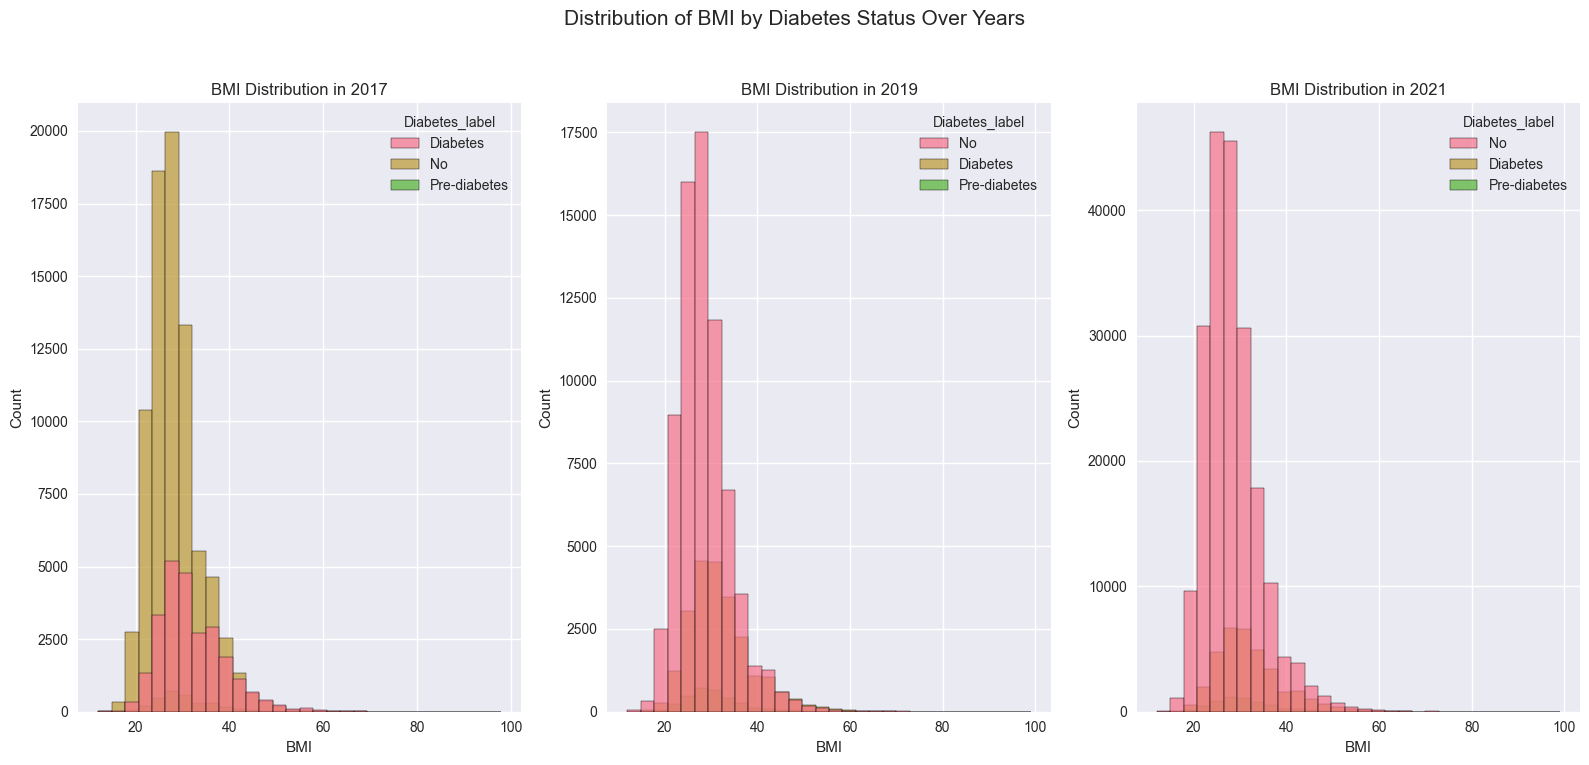

In [6]:
# Distribution of BMI by Diabetes status over years
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="BMI",
)

#### **2.1.2 Age distribution**

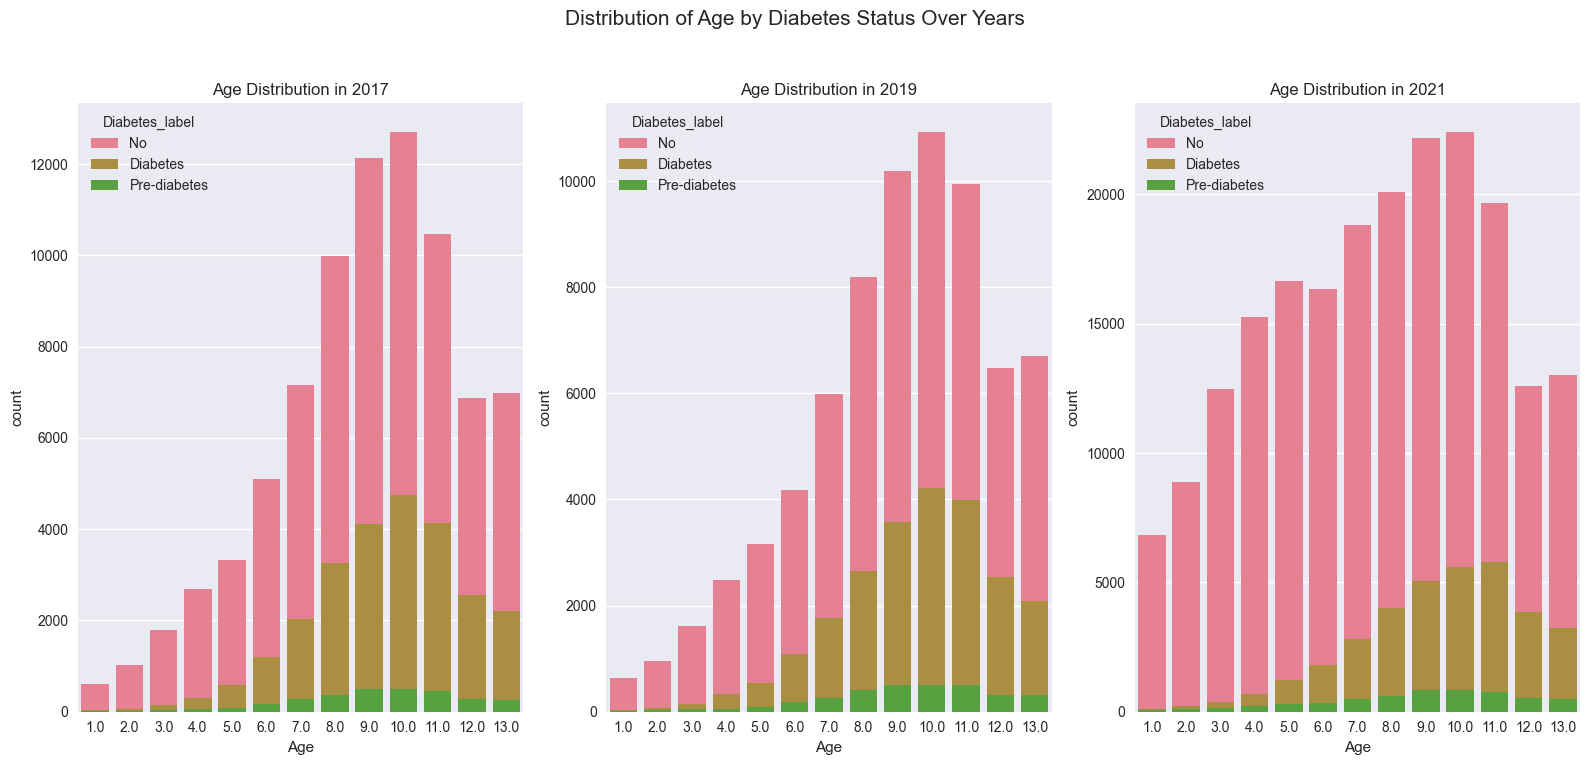

In [7]:
# Distribution of Age by Diabetes status over years
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="Age"
)

#### **2.1.3 General health status (GenHlth)**

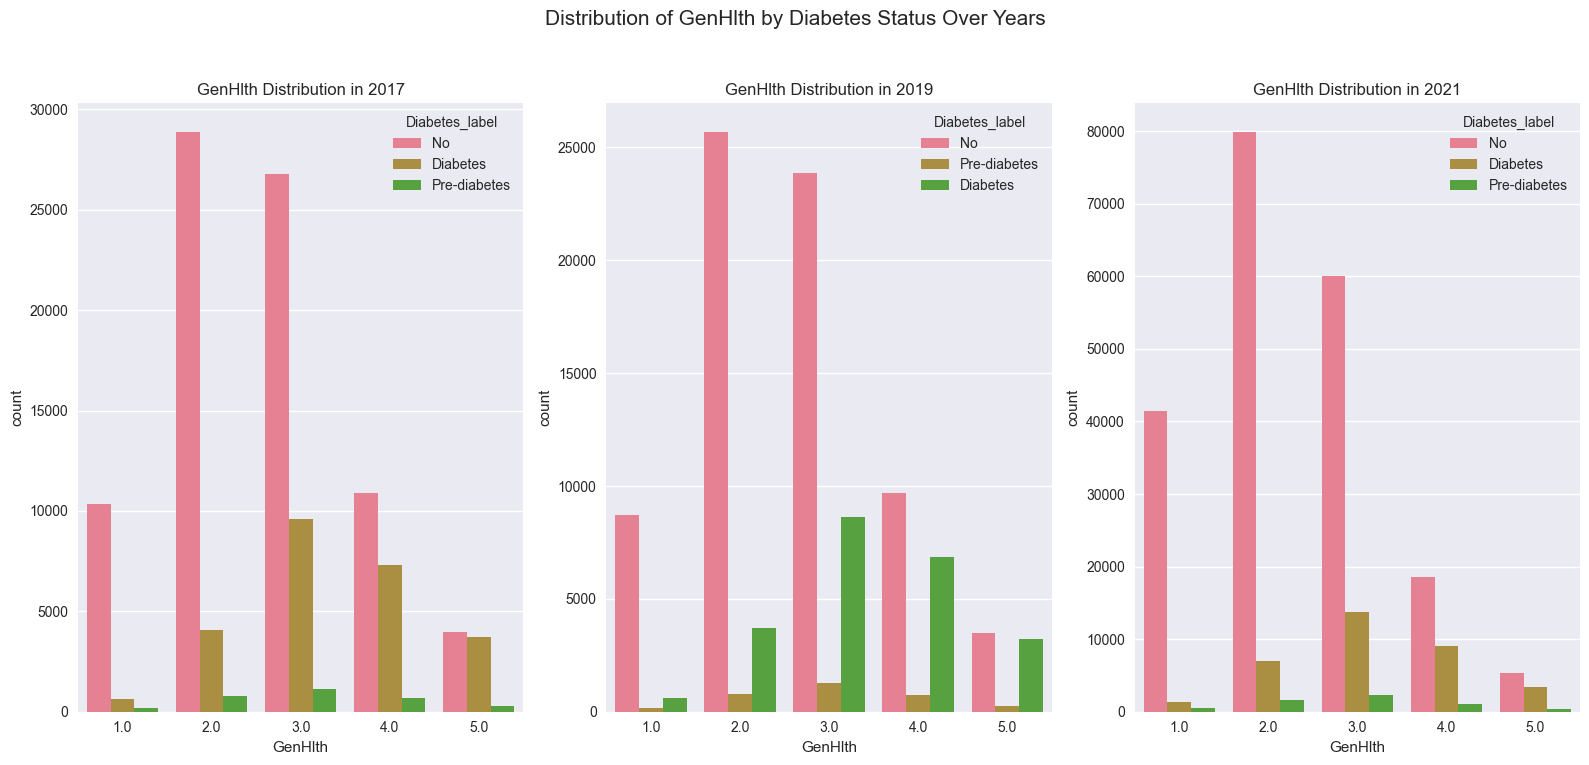

In [8]:
# Distribution of General Health by Diabetes status over years
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="GenHlth"
)

#### **2.1.4 Access to health services (NoDocbcCost)**

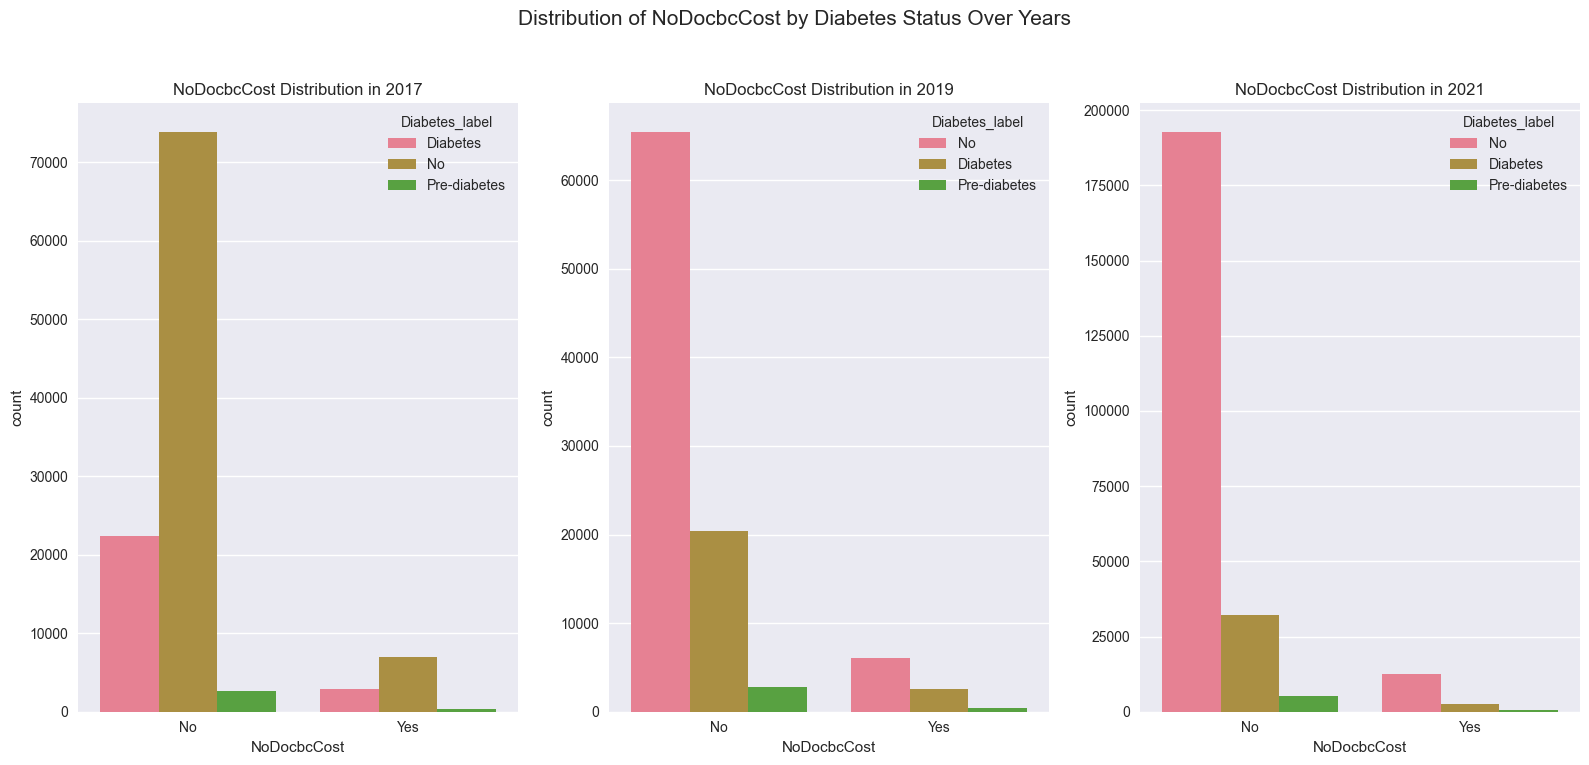

In [9]:
plot_feature_distributions_comparison(
    df_list=[df_2017, df_2019, df_2021],
    year_list=[2017, 2019, 2021],
    feature="NoDocbcCost",
)

#### **2.1.5 Distribution of continuous features**

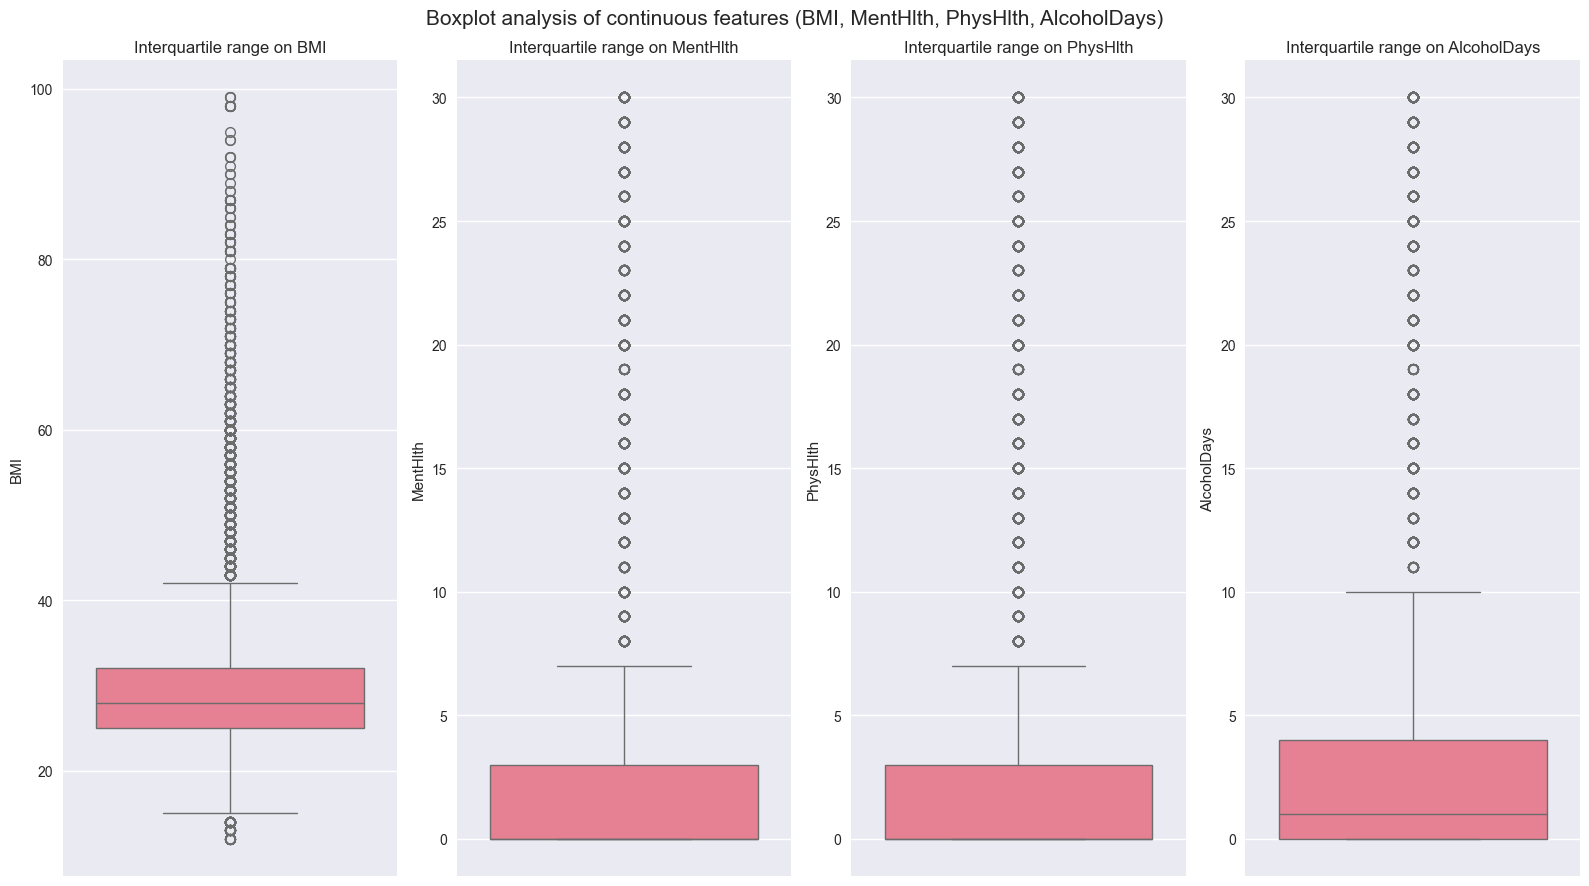

In [10]:
# Draw boxplot to identify outlier
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 9))

sns.boxplot(data=df, y='BMI', ax=ax[0])
ax[0].set_title('Interquartile range on BMI')

sns.boxplot(data=df, y='MentHlth', ax=ax[1])
ax[1].set_title('Interquartile range on MentHlth')

sns.boxplot(data=df, y='PhysHlth', ax=ax[2])
ax[2].set_title('Interquartile range on PhysHlth')

sns.boxplot(data=df, y='AlcoholDays', ax=ax[3])
ax[3].set_title('Interquartile range on AlcoholDays')

plt.suptitle(t="Boxplot analysis of continuous features (BMI, MentHlth, PhysHlth, AlcoholDays)", fontsize=15)
plt.tight_layout()
plt.show()

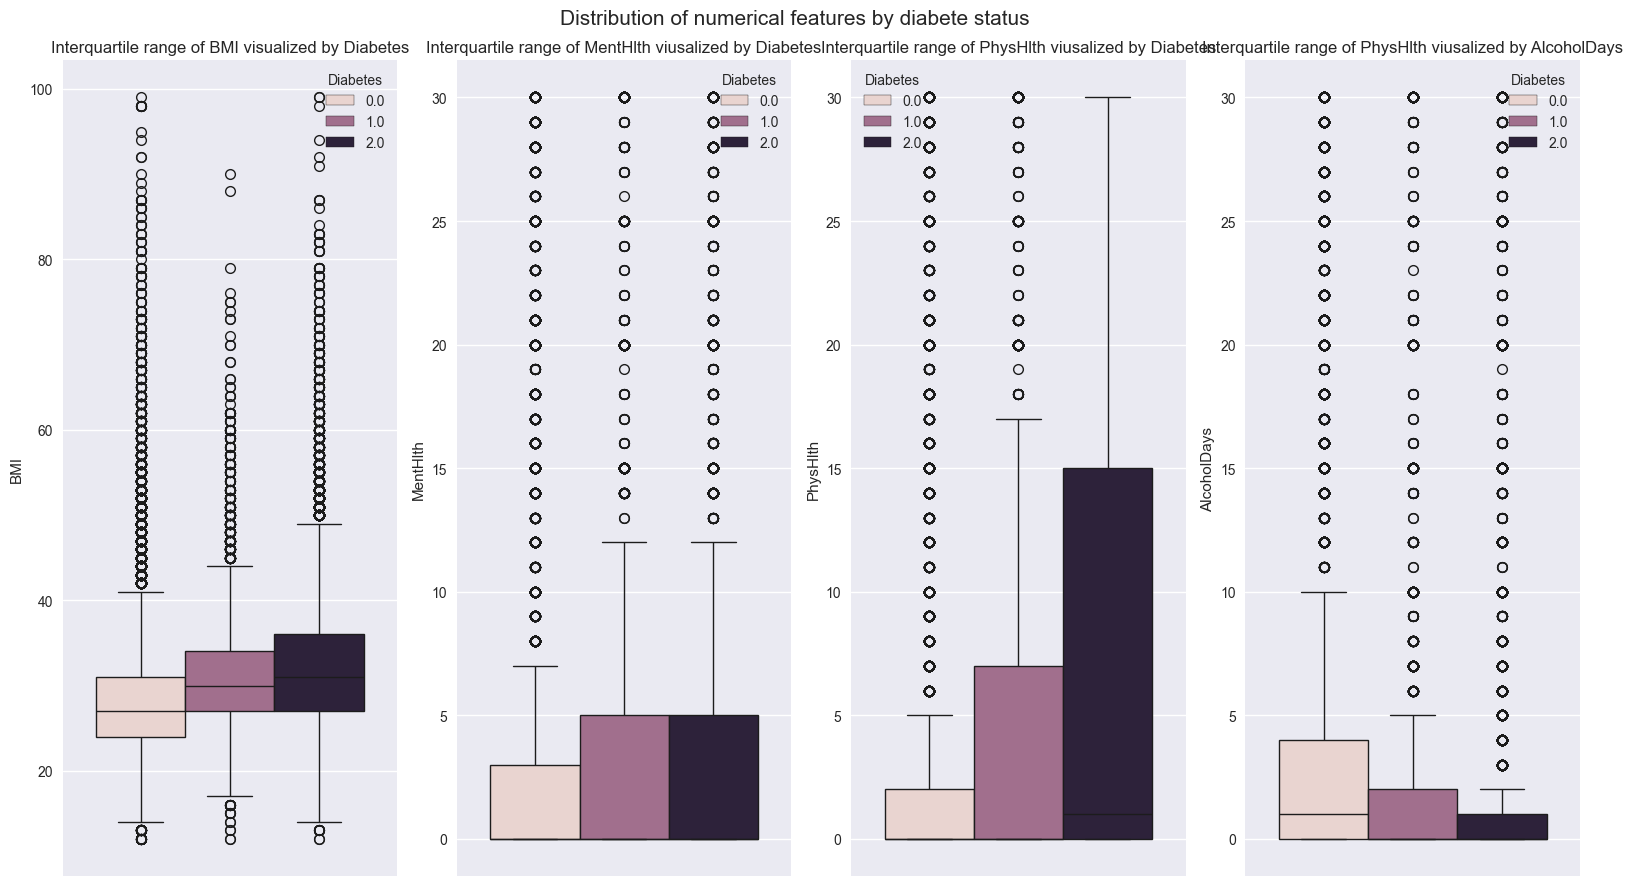

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 9))

sns.boxplot(data=df, y='BMI', hue='Diabetes', ax=ax[0])
ax[0].set_title('Interquartile range of BMI visualized by Diabetes')

sns.boxplot(data=df, y='MentHlth', hue='Diabetes', ax=ax[1])
ax[1].set_title('Interquartile range of MentHlth viusalized by Diabetes')

sns.boxplot(data=df, y='PhysHlth', hue='Diabetes', ax=ax[2])
ax[2].set_title('Interquartile range of PhysHlth viusalized by Diabetes')

sns.boxplot(data=df, y='AlcoholDays', hue='Diabetes', ax=ax[3])
ax[3].set_title('Interquartile range of PhysHlth viusalized by AlcoholDays')

plt.suptitle(t="Distribution of numerical features by diabete status", fontsize=15)
plt.tight_layout()
plt.show()

### **2.2 Physical health indicators over years**

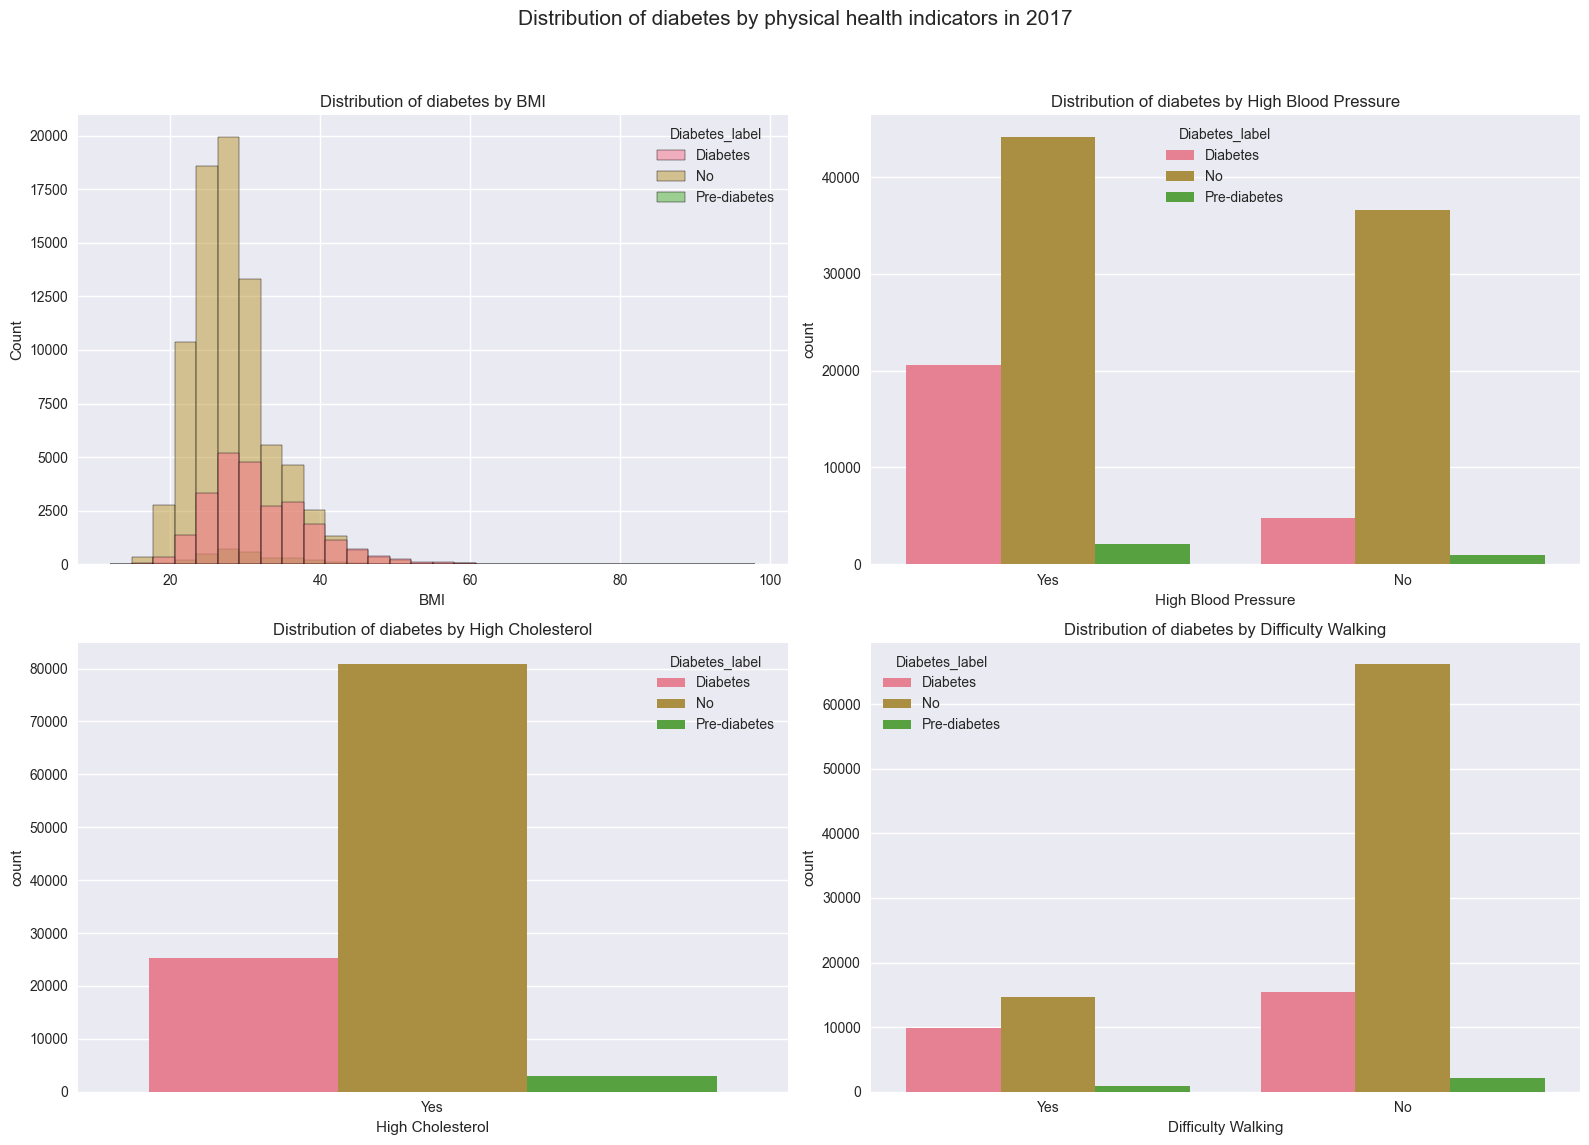

In [12]:
# Distribution of diabetes by physical health indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2017,
    title="Distribution of diabetes by physical health indicators"
)

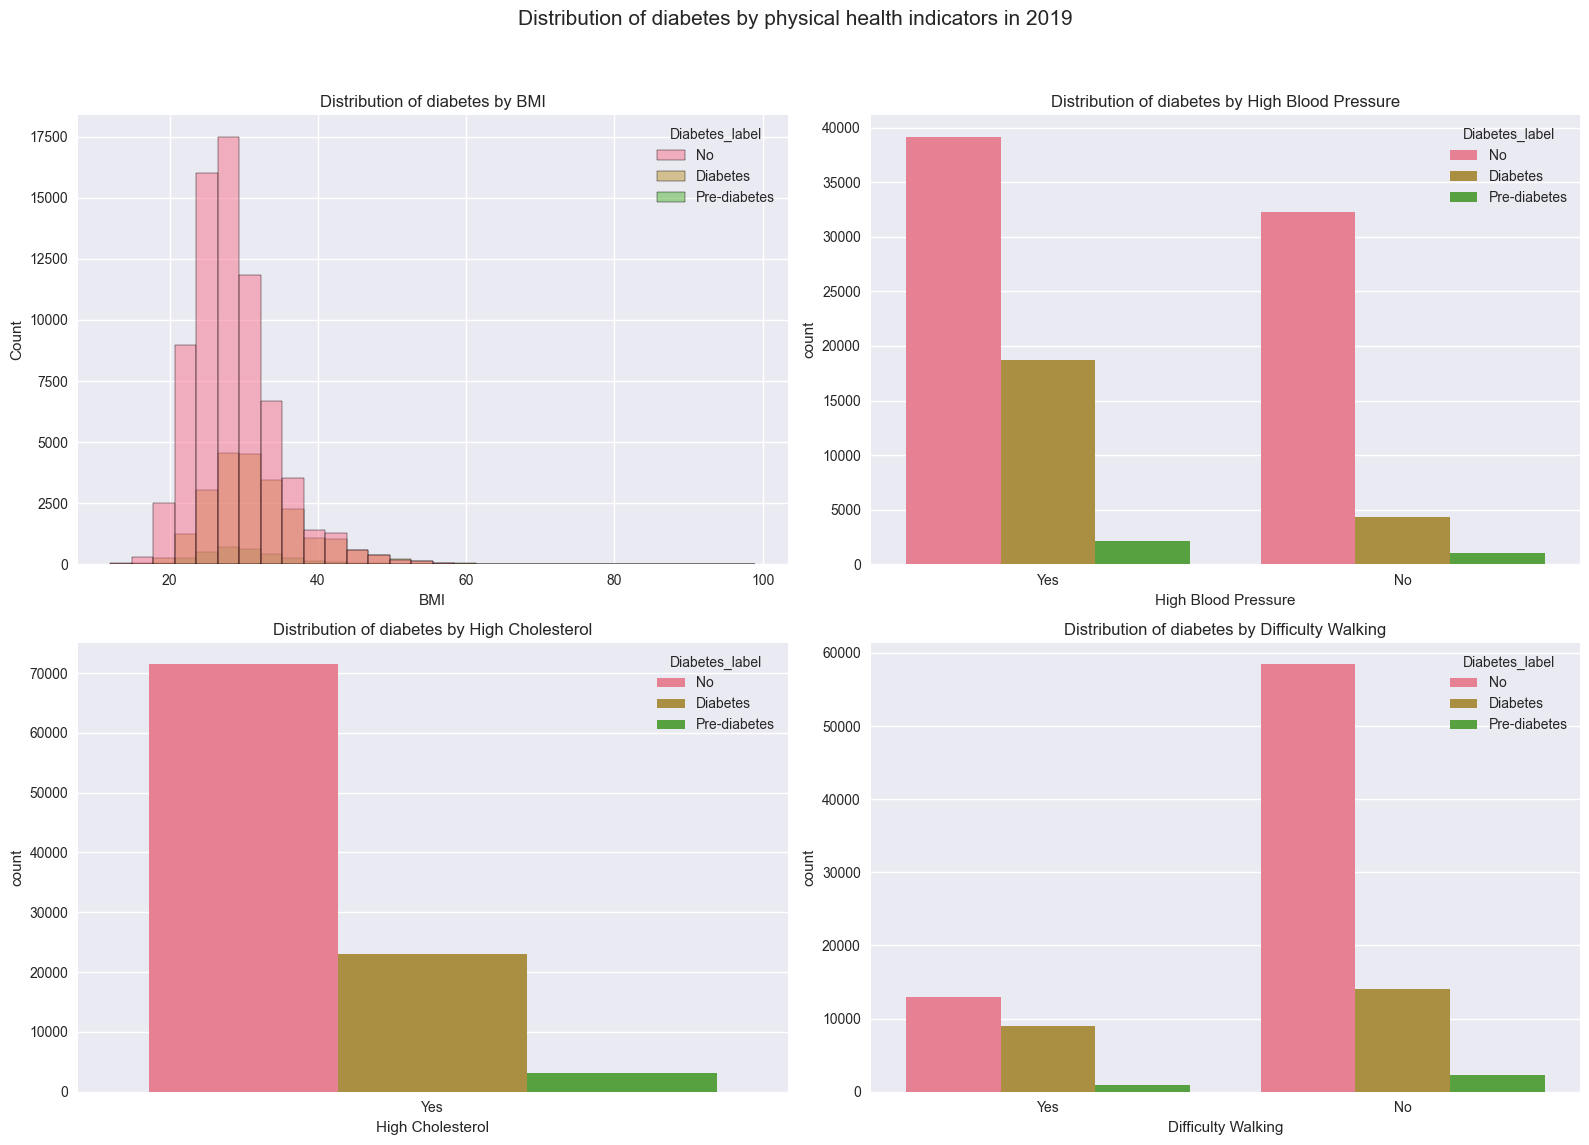

In [13]:
# Distribution of diabetes by physical health indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2019,
    title="Distribution of diabetes by physical health indicators"
)

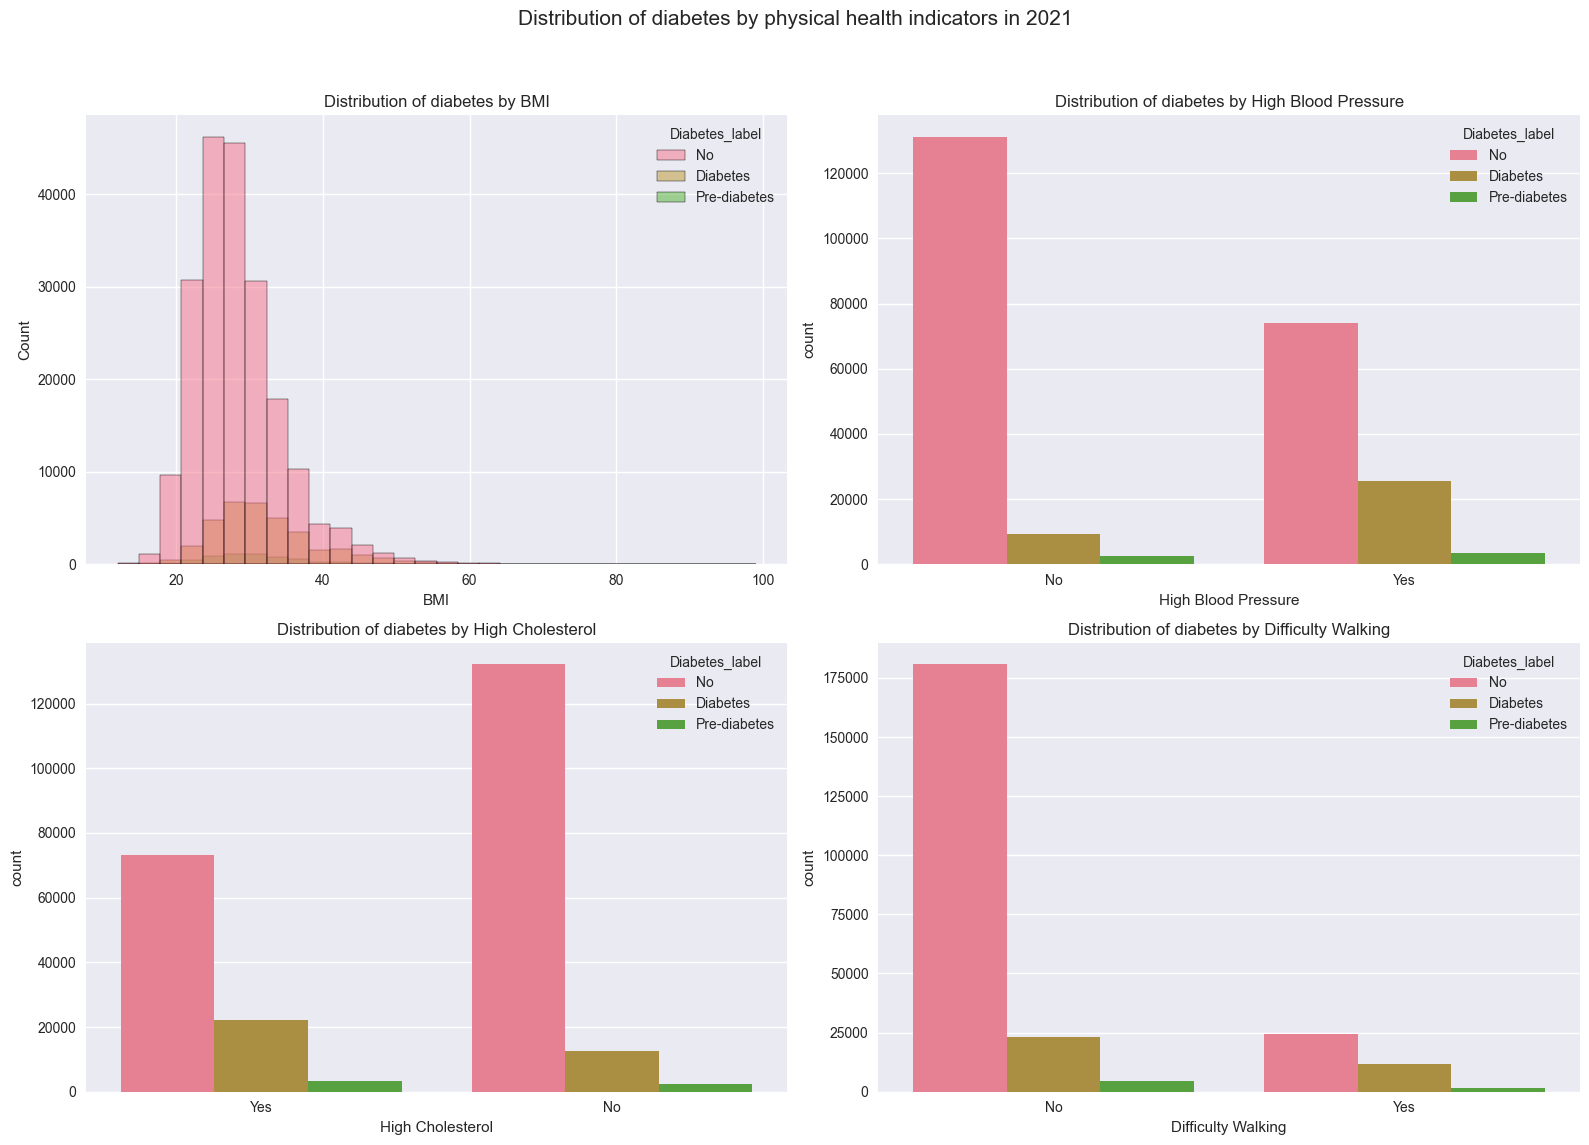

In [14]:
# Distribution of diabetes by physical health indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2021,
    title="Distribution of diabetes by physical health indicators"
)

### **2.3 Distribution of diabetes by demographics & lifestyle indicators**

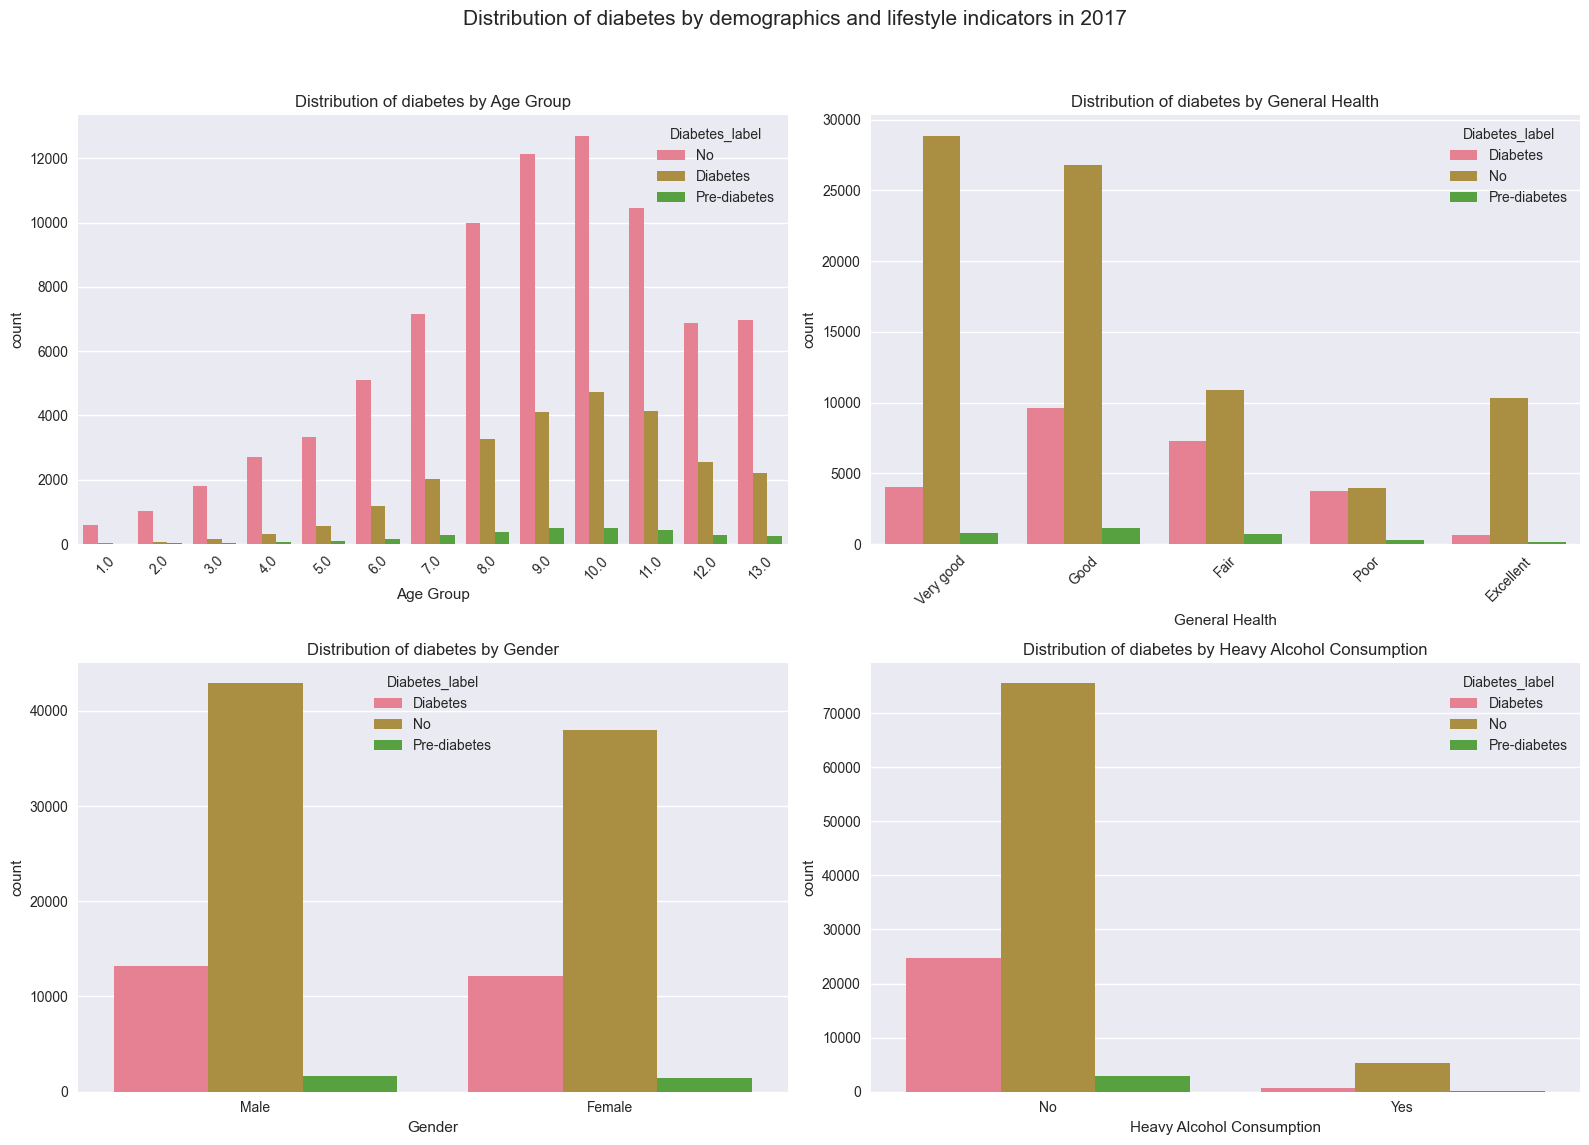

In [15]:
# Distribution of diabetes by demographics and lifestyle indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2017,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

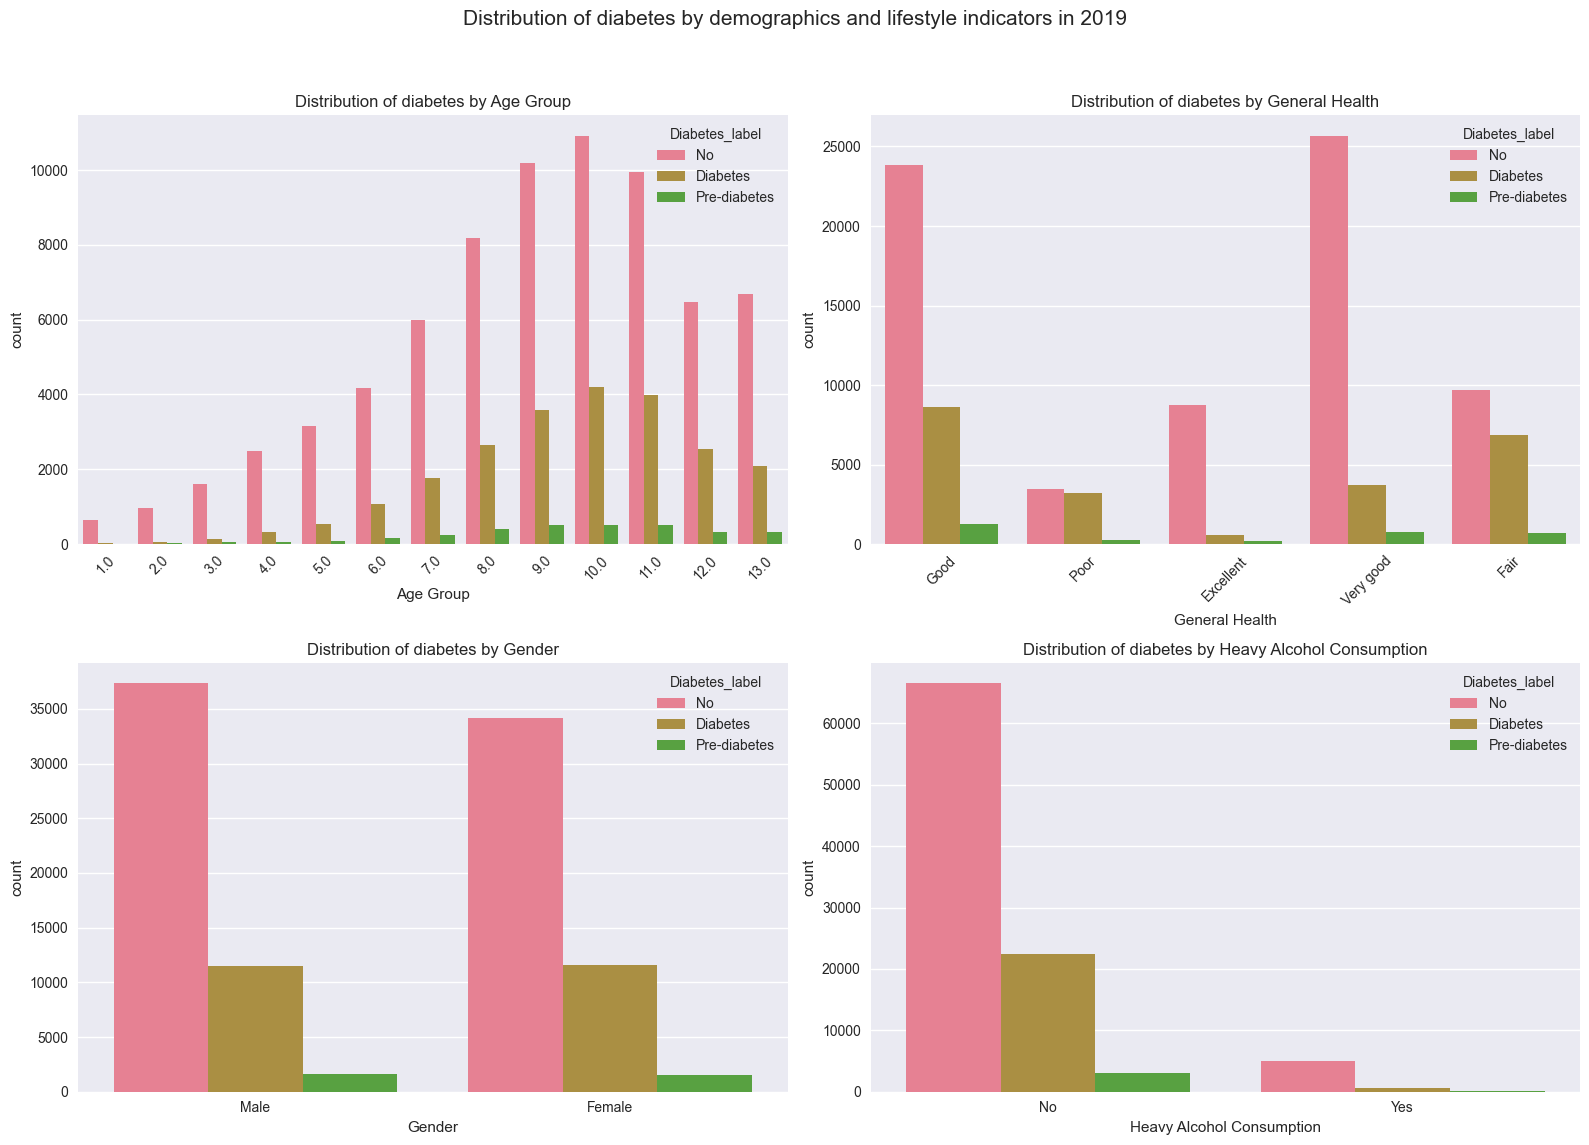

In [16]:
# Distribution of diabetes by demographics and lifestyle indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2019,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

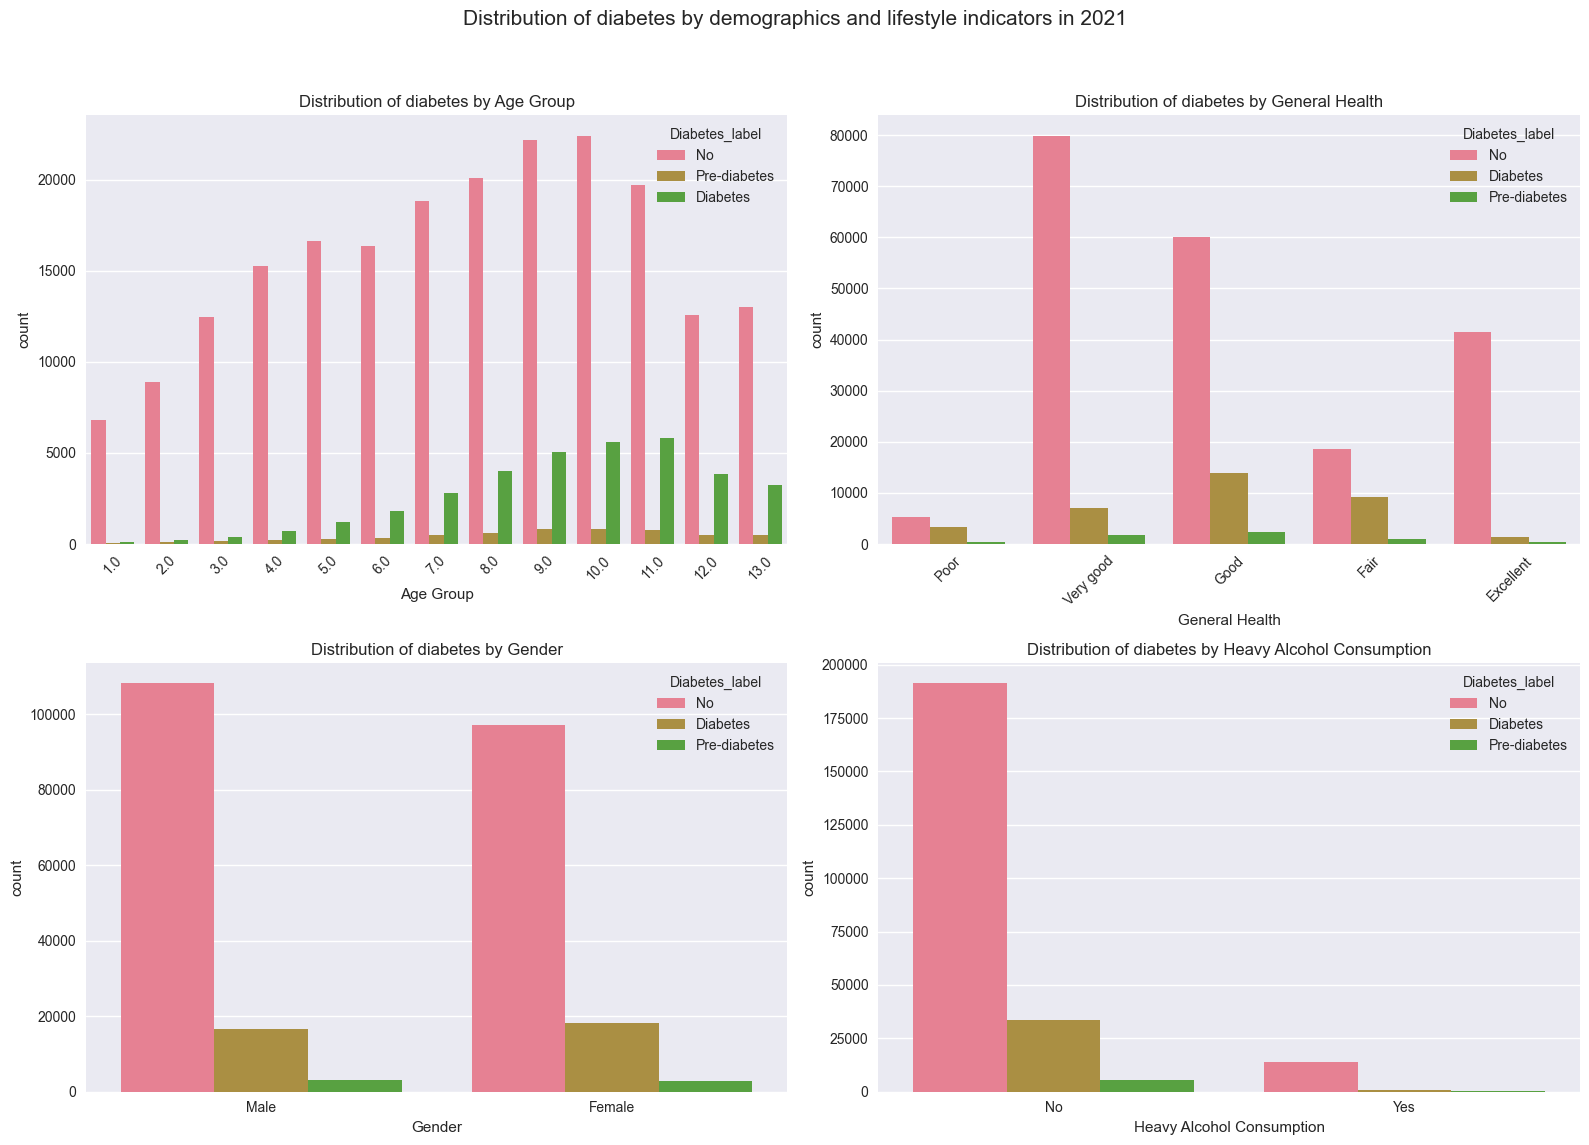

In [17]:
# Distribution of diabetes by demographics and lifestyle indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2021,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

### **2.4 Distribution of diabetes by mental & general health indicators**

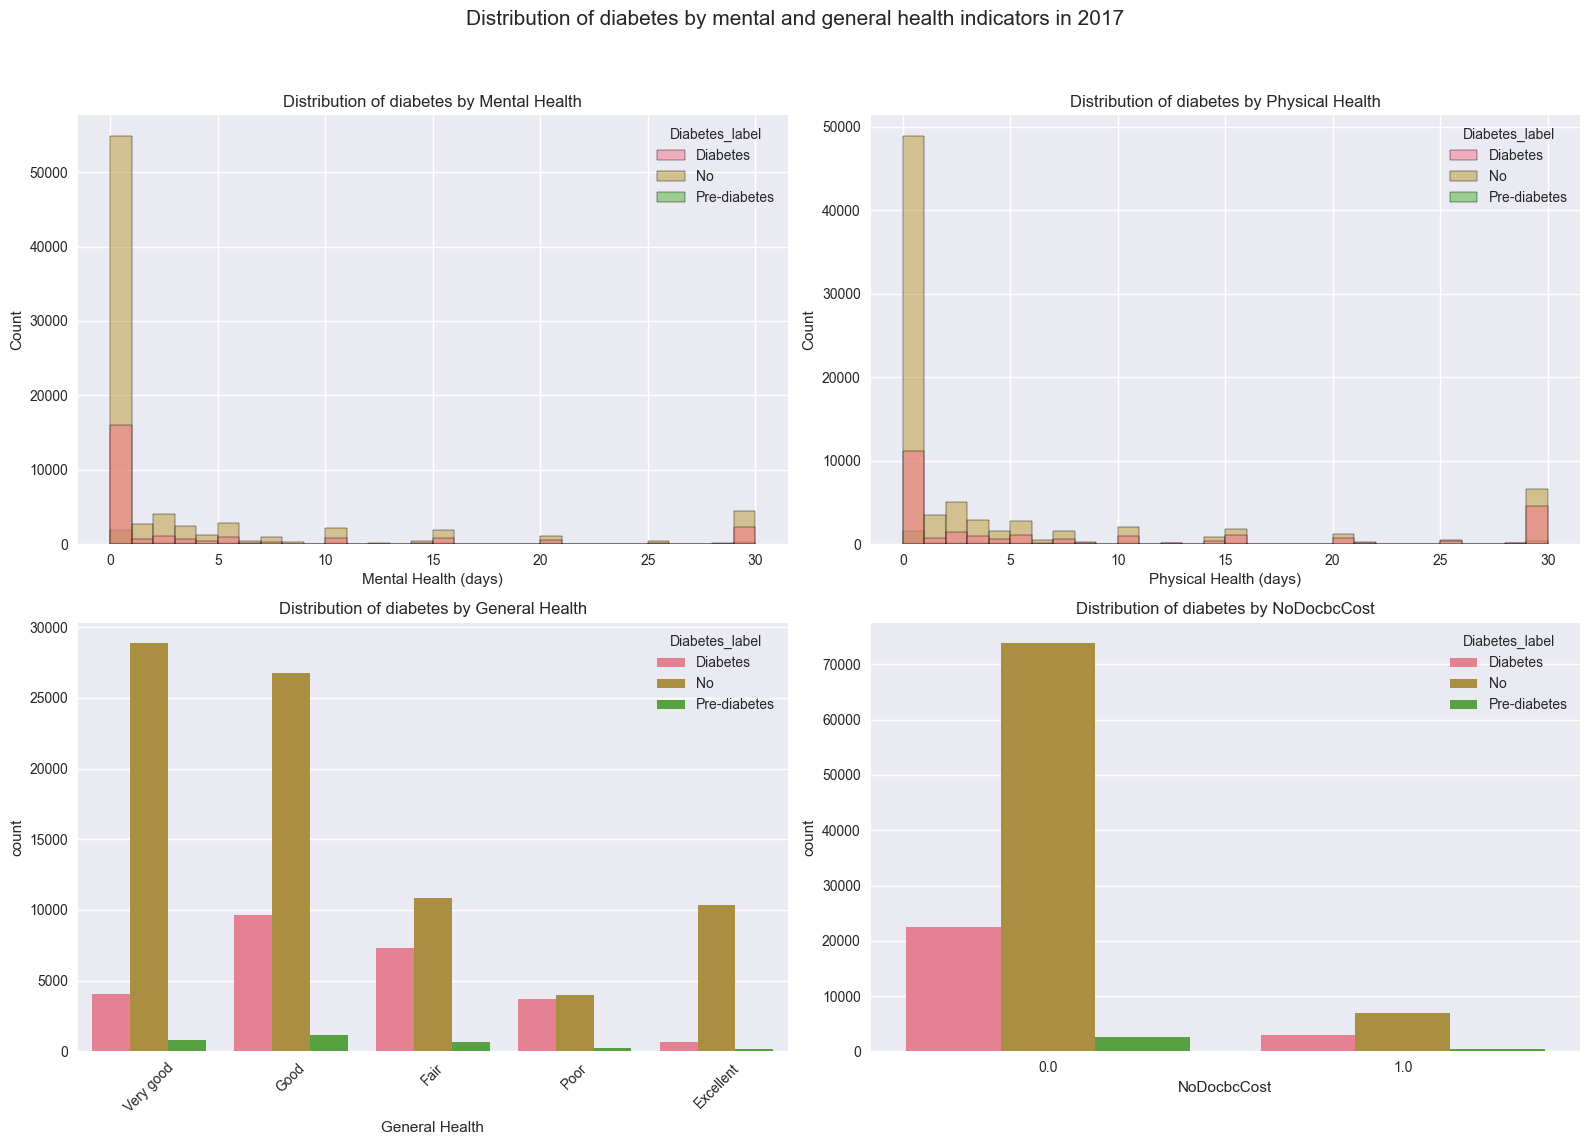

In [18]:
# Distribution of diabetes by mental and general health indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2017,
    title="Distribution of diabetes by mental and general health indicators"
)


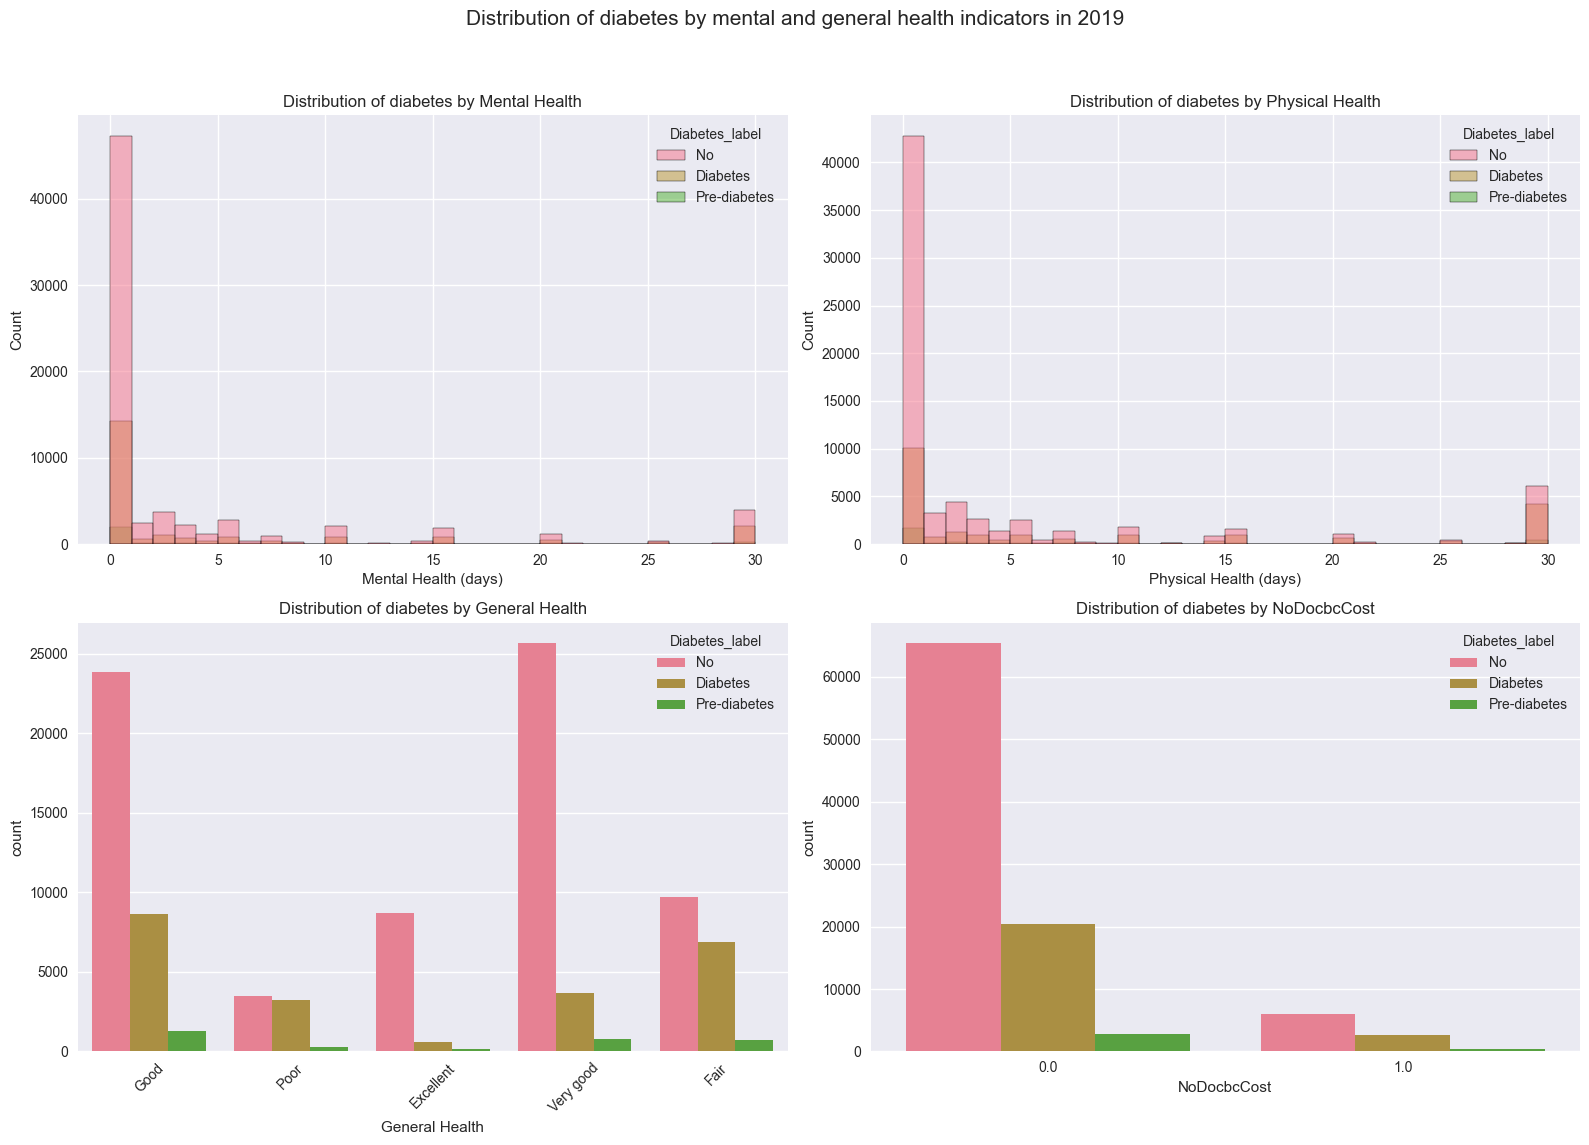

In [19]:
# Distribution of diabetes by mental and general health indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2019,
    title="Distribution of diabetes by mental and general health indicators"
)

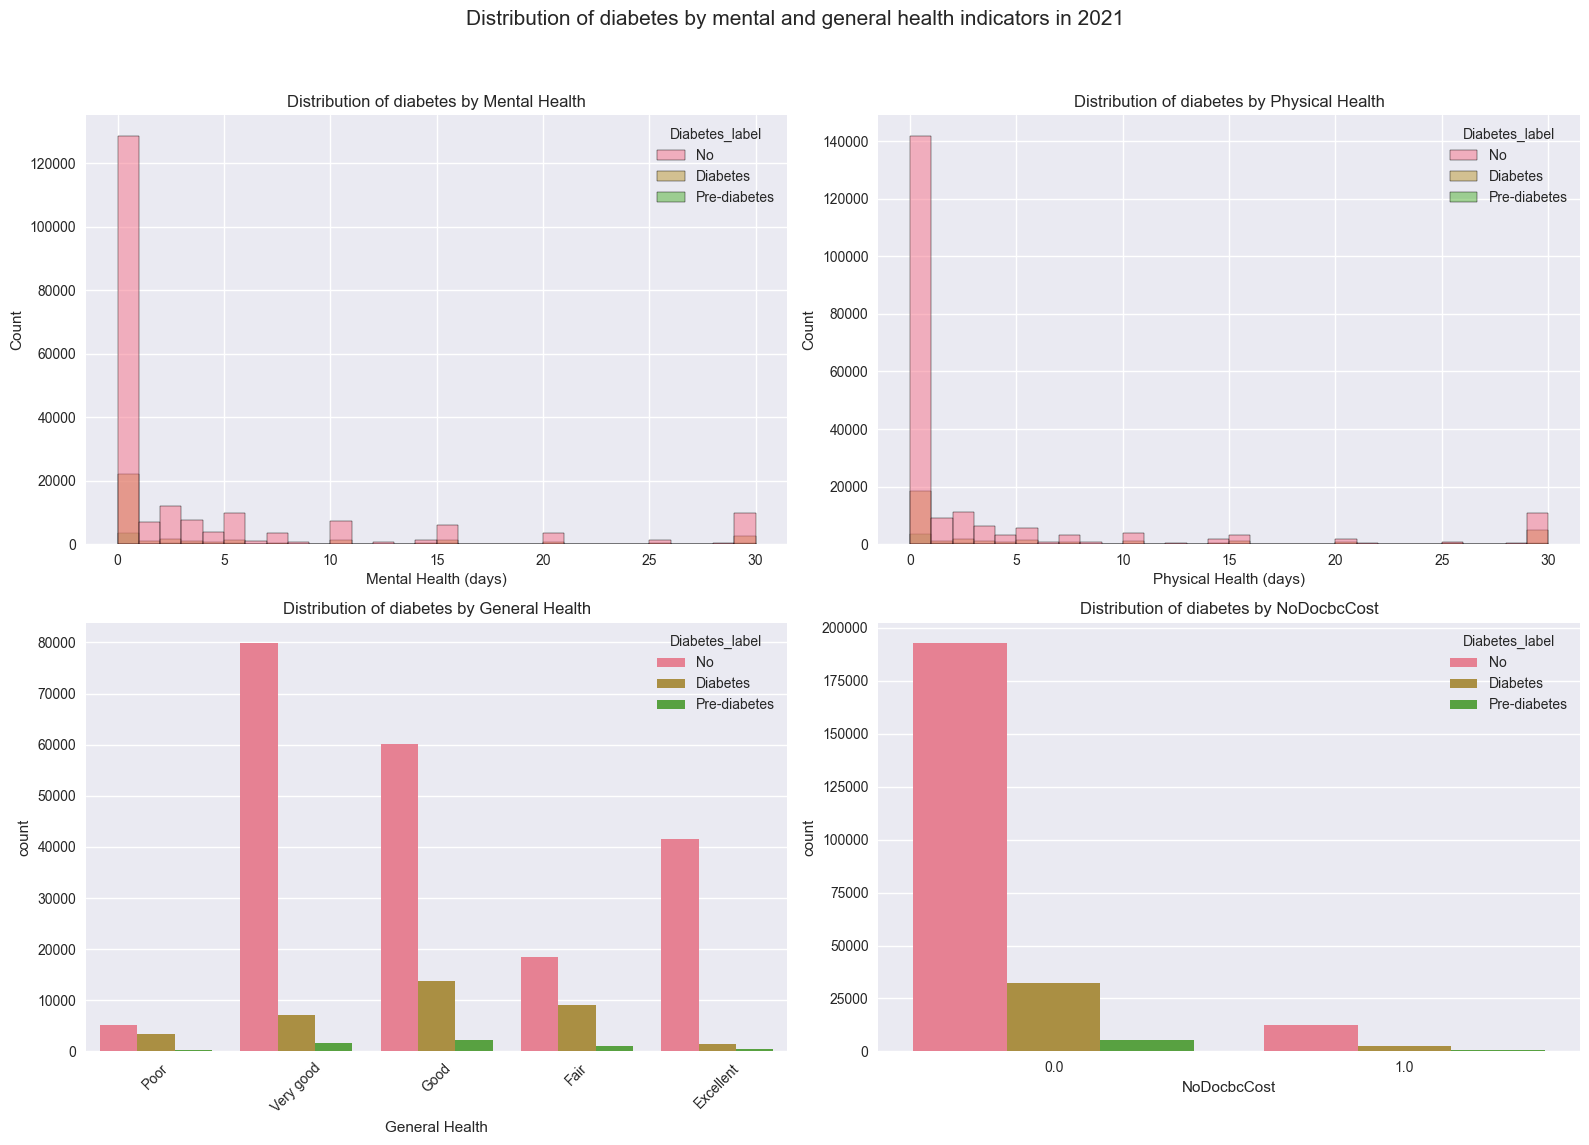

In [20]:
# Distribution of diabetes by mental and general health indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2021,
    title="Distribution of diabetes by mental and general health indicators"
)

### **2.5 Distribution of diabetes by behavioral health indicators over years**

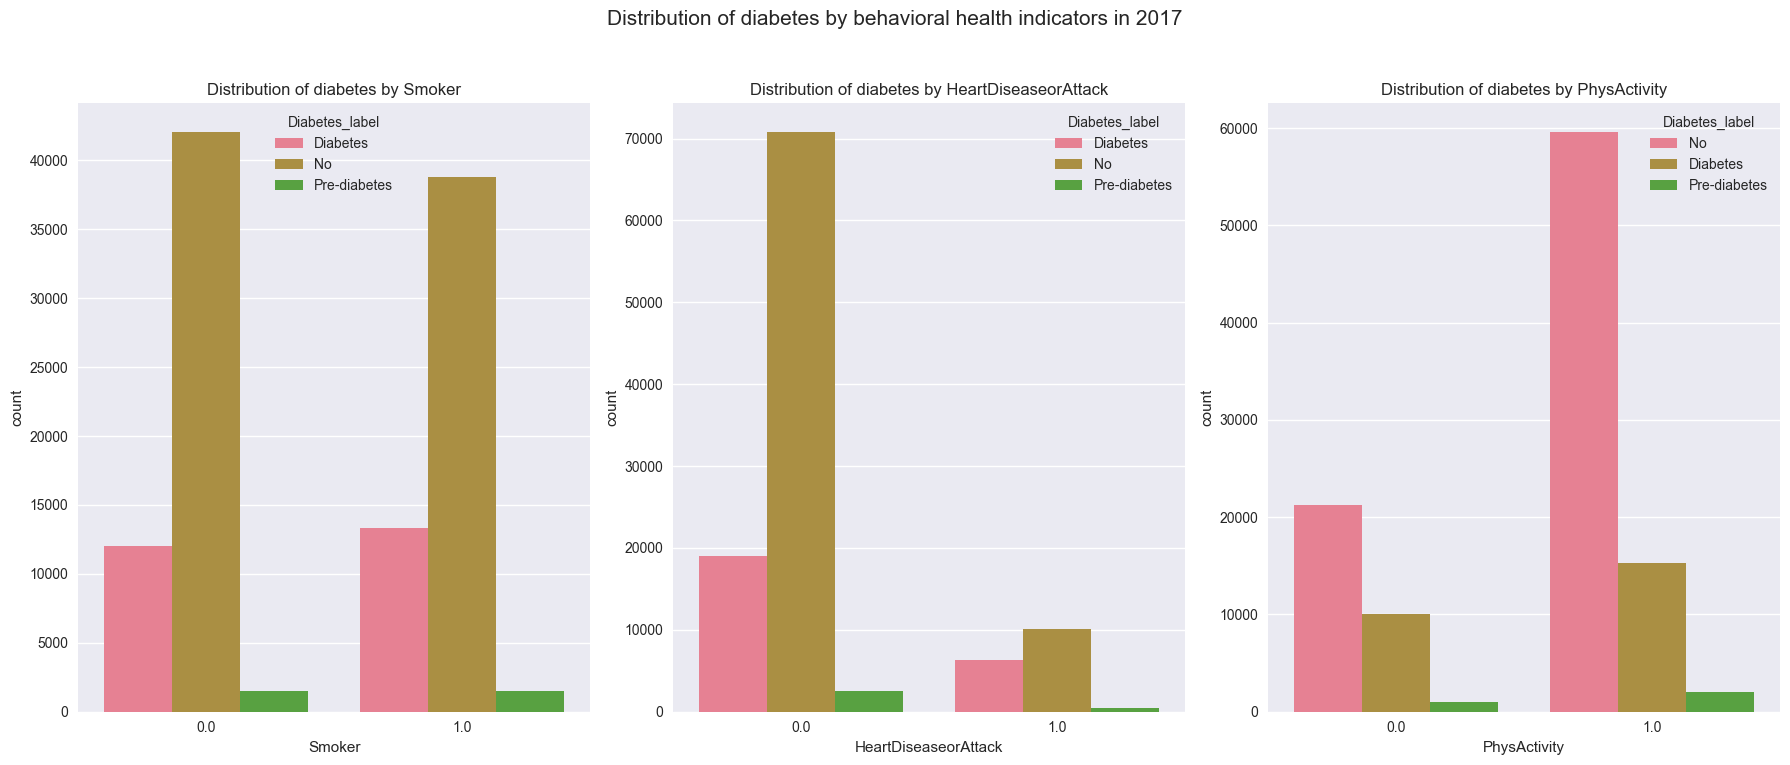

In [21]:
# Distribution of diabetes by behavioral health indicators in 2017
plot_diabetes_distribution_by_indicators(
    df=df_2017,
    indicators=["Smoker", "HeartDiseaseorAttack", "PhysActivity"],
    year=2017,
    title="Distribution of diabetes by behavioral health indicators",
    figsize=(18, 8)
)

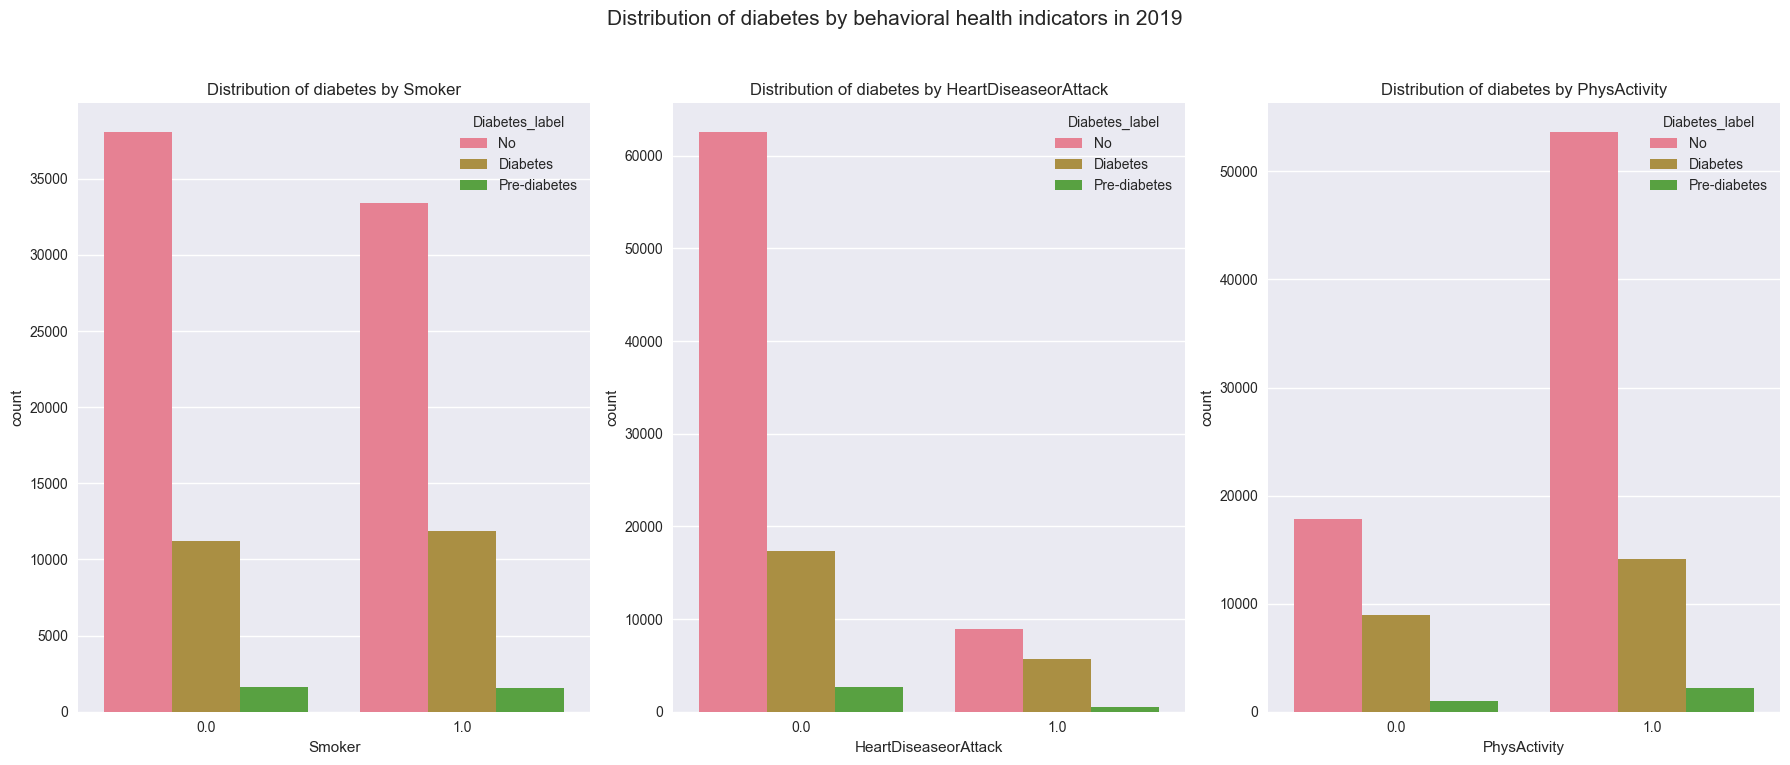

In [22]:
# Distribution of diabetes by behavioral health indicators in 2019
plot_diabetes_distribution_by_indicators(
    df=df_2019,
    indicators=["Smoker", "HeartDiseaseorAttack", "PhysActivity"],
    year=2019,
    title="Distribution of diabetes by behavioral health indicators",
    figsize=(18, 8)
)

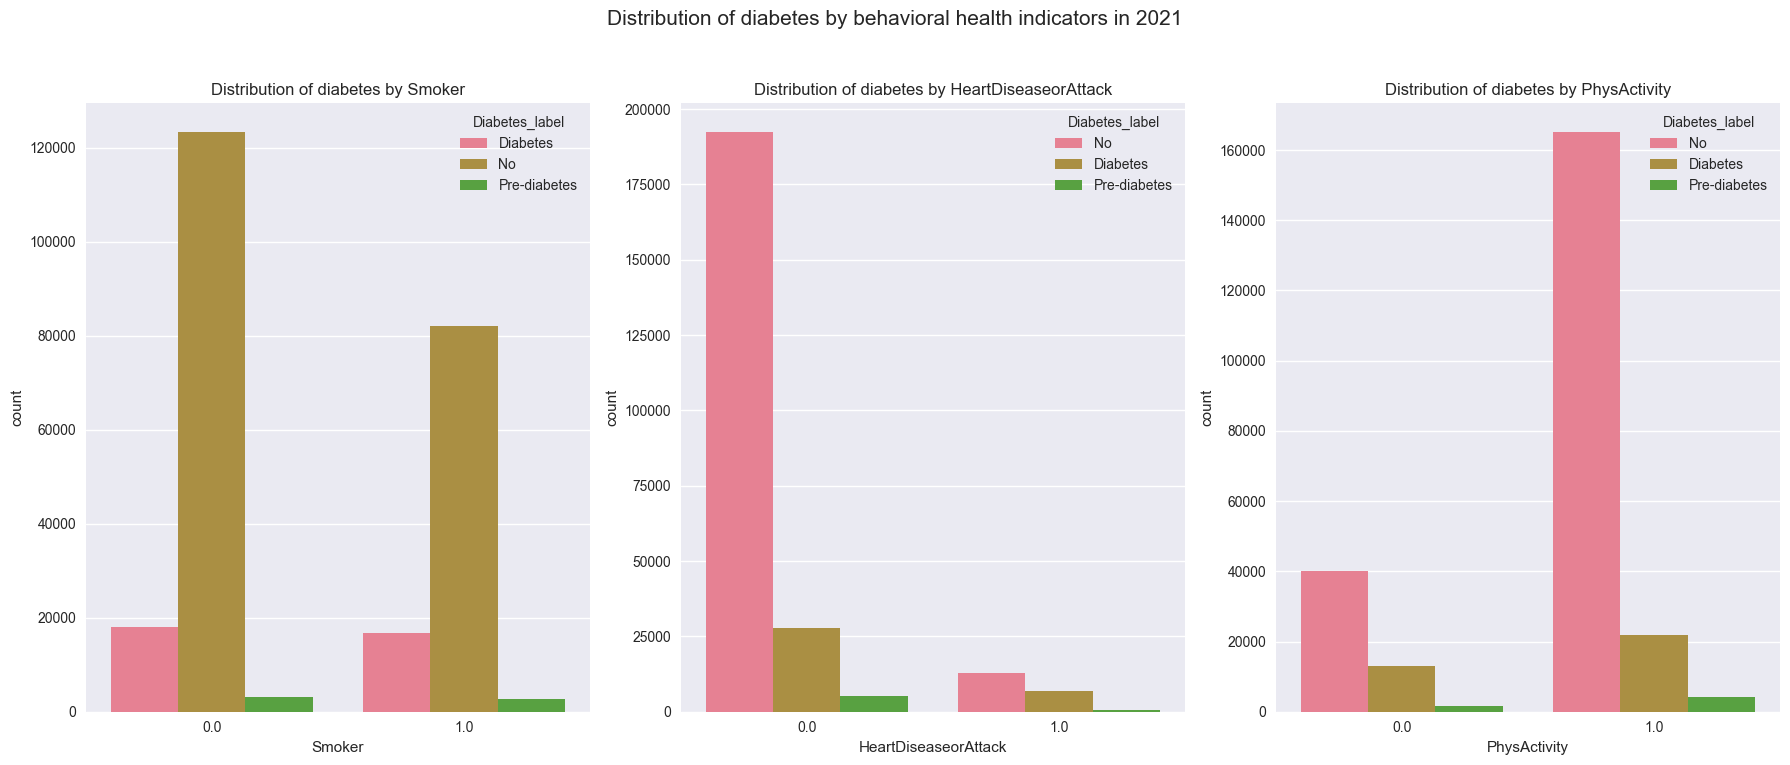

In [23]:
# Distribution of diabetes by behavioral health indicators in 2021
plot_diabetes_distribution_by_indicators(
    df=df_2021,
    indicators=["Smoker", "HeartDiseaseorAttack", "PhysActivity"],
    year=2021,
    title="Distribution of diabetes by behavioral health indicators",
    figsize=(18, 8)
)

### **2.6 Feature interaction analysis**

Scatter plot shows:

- **High-risk area**: Concentrated in the upper right corner (BMI >30, age >50), where the density of red dots (diabetes) is highest. This confirms the synergistic effect of obesity and aging.
- **Low-risk area**: The lower left corner (BMI <25, age <40) has the highest density of green dots (no disease).
- **Time trend**: Over 3 years, this pattern remains stable, showing the sustainability of the relationship between these two factors.

Text(0.5, 1.0, 'The distribution of diabetes by Age and BMI in 2017')

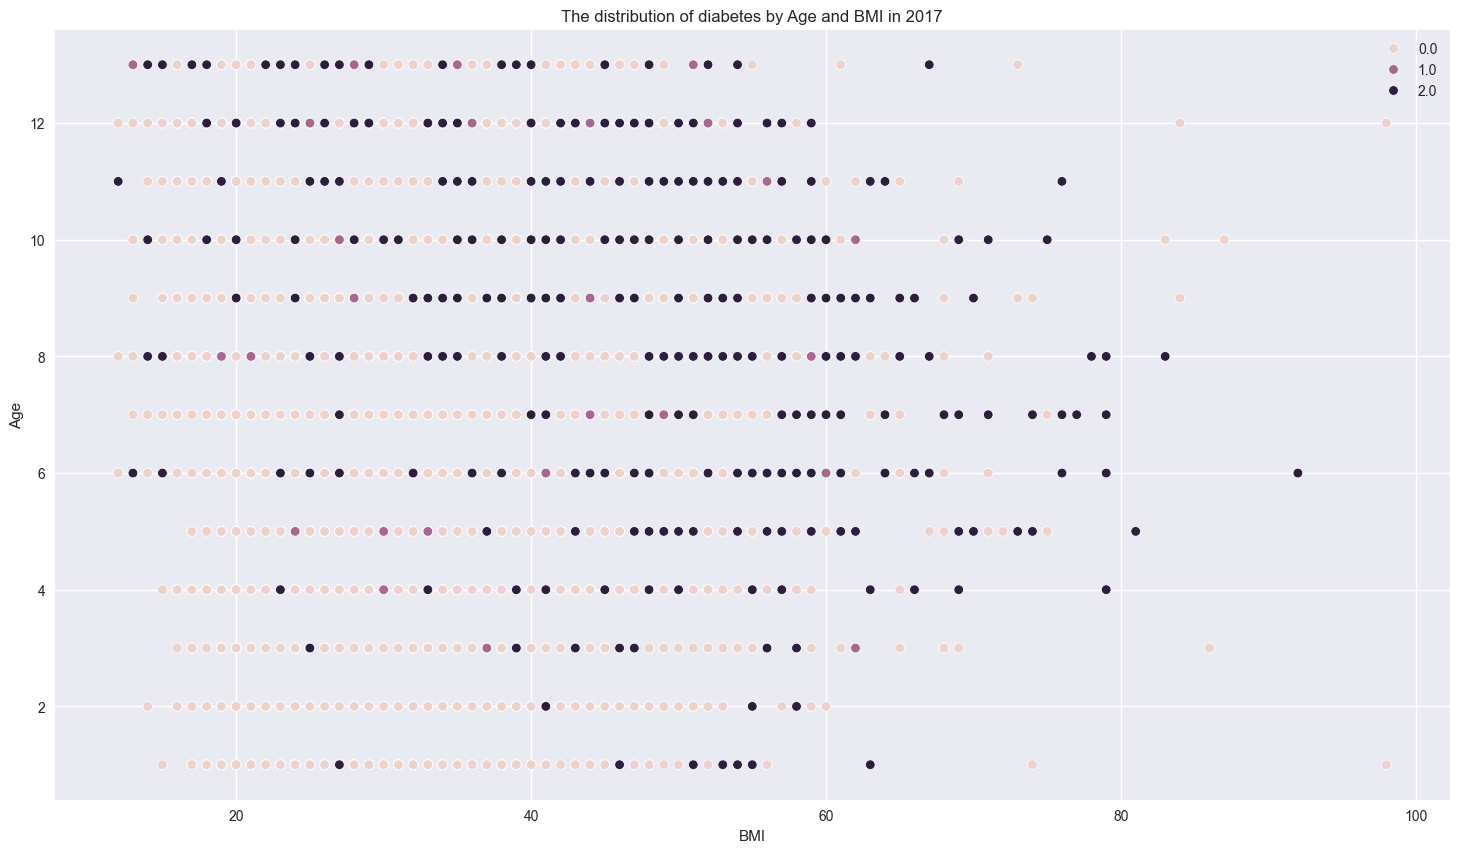

In [24]:
# Interaction analysis of BMI and Age by Diabetes status in 2017
plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_2017, x='BMI', y='Age', hue='Diabetes')
plt.legend(loc="best")
plt.title(label="The distribution of diabetes by Age and BMI in 2017")

Text(0.5, 1.0, 'The distribution of diabetes by Age and BMI in 2019')

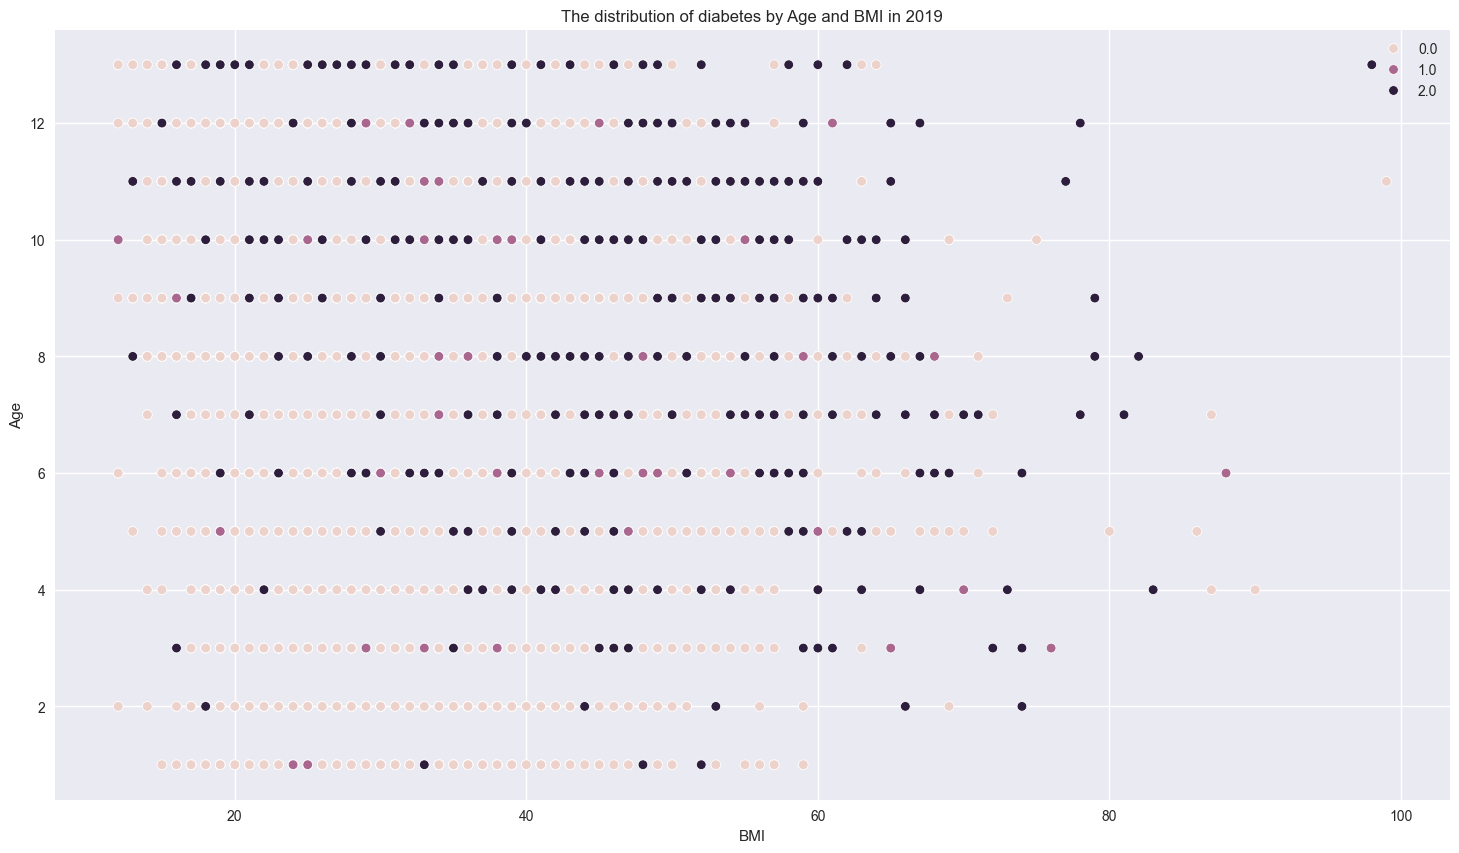

In [25]:
# Interaction analysis of BMI and Age by Diabetes status in 2019
plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_2019, x='BMI', y='Age', hue='Diabetes')
plt.legend(loc="best")
plt.title(label="The distribution of diabetes by Age and BMI in 2019")

Text(0.5, 1.0, 'The distribution of diabetes by Age and BMI in 2021')

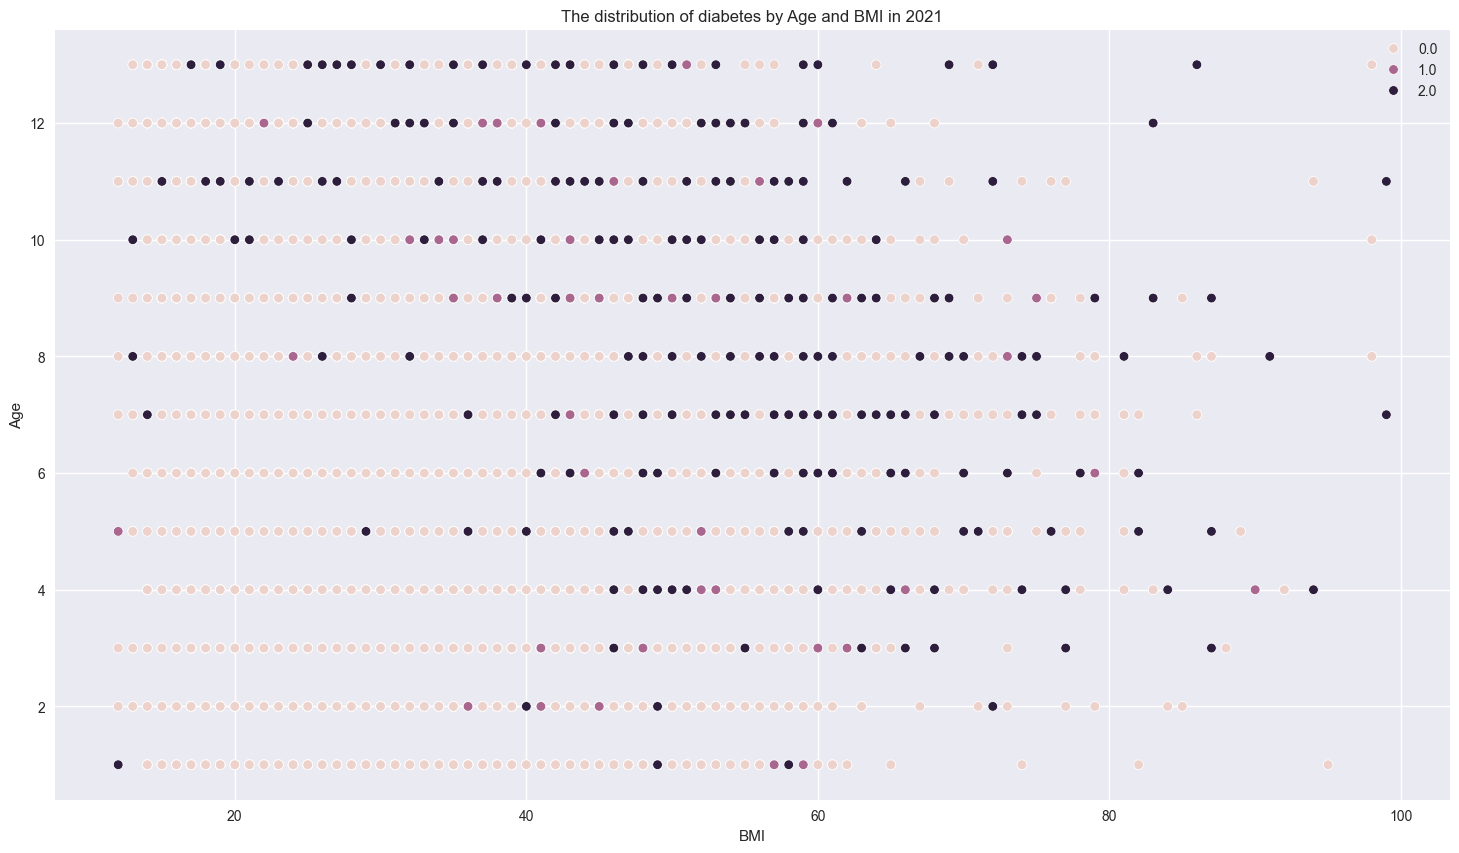

In [26]:
# Interaction analysis of BMI and Age by Diabetes status in 2021
plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_2021, x='BMI', y='Age', hue='Diabetes')
plt.legend(loc="best")
plt.title(label="The distribution of diabetes by Age and BMI in 2021")

### **2.7 Cross-tabulation analysis**

In [27]:
# Cross-tabulation analysis: High BP vs Diabetes
pd.crosstab(index=df['HighBP'], columns=df['Diabetes'], normalize='index')

Diabetes,0.0,1.0,2.0
HighBP,,,
0.0,0.897855,0.019641,0.082504
1.0,0.684932,0.033148,0.281920


In [28]:
# Cross-tabulation analysis: Age vs Diabetes
pd.crosstab(index=df['Age'], columns=df['Diabetes'], normalize='index')

Diabetes,0.0,1.0,2.0
Age,,,
1.0,0.970673,0.009615,0.019712
2.0,0.956048,0.013361,0.030591
3.0,0.945758,0.013873,0.040369
4.0,0.924015,0.015992,0.059993
5.0,0.891779,0.018075,0.090145
6.0,0.842916,0.022690,0.134394
7.0,0.806727,0.025988,0.167285
8.0,0.771749,0.027977,0.200274
9.0,0.753256,0.031276,0.215467


### **2.8 Comprehensive feature analysis**

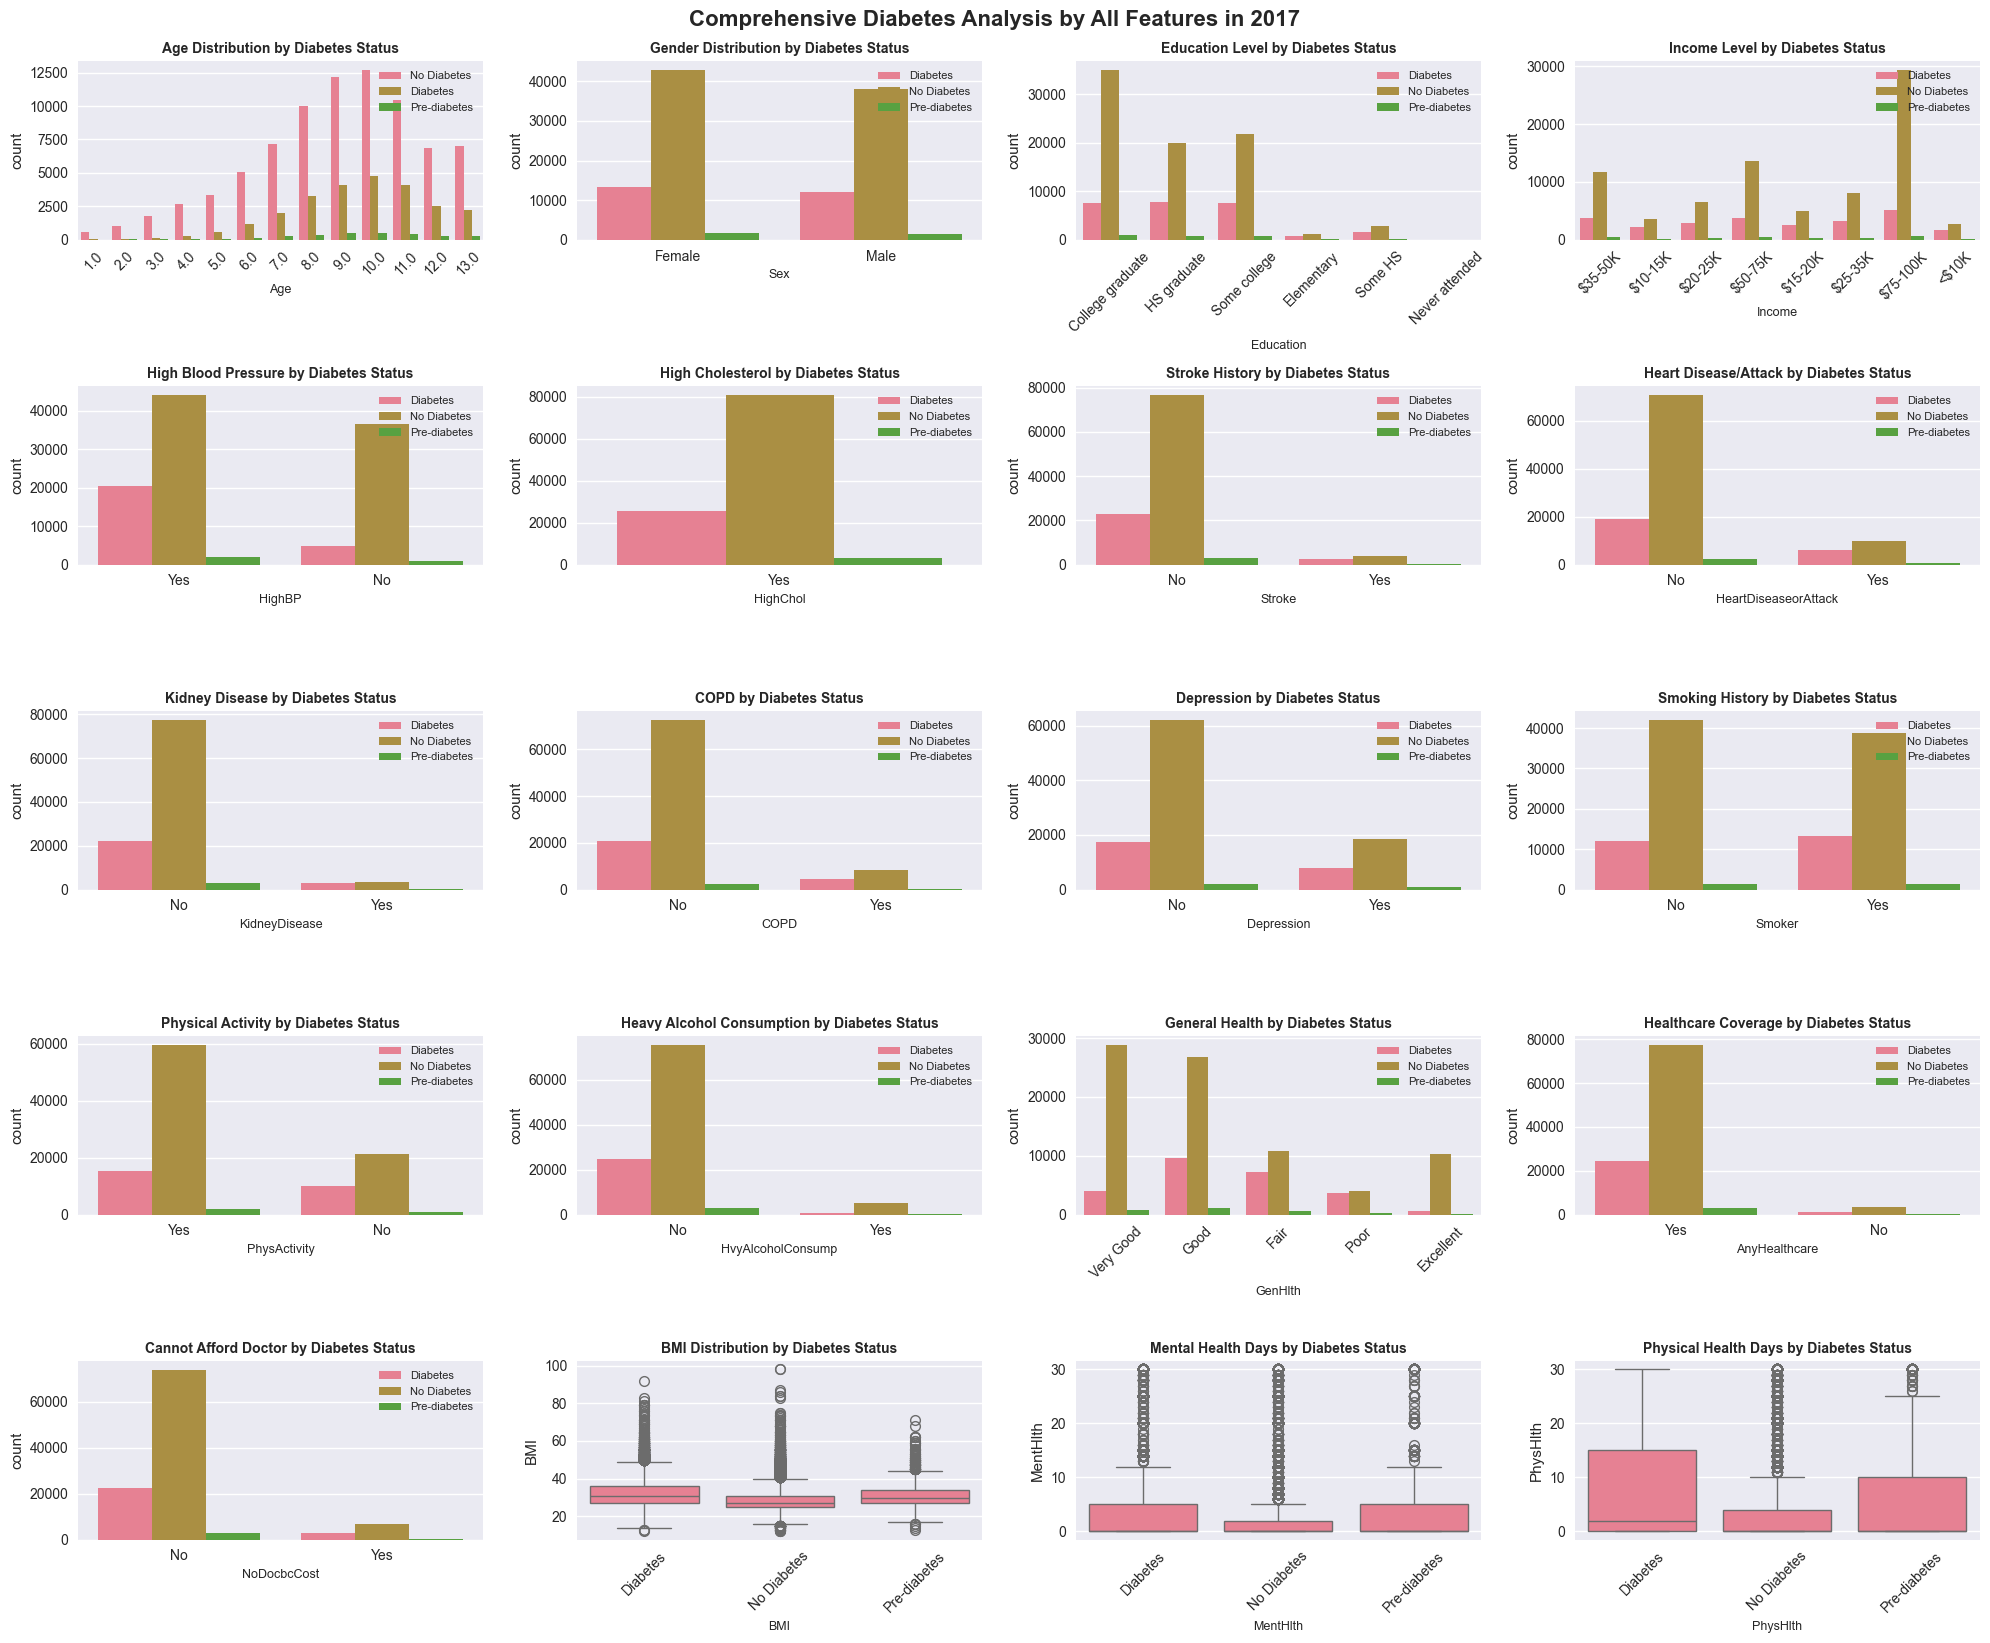

In [29]:
# Comprehensive feature and diabetes analysis in 2017
plot_comprehensive_diabetes_analysis(df=df_2017, year=2017)

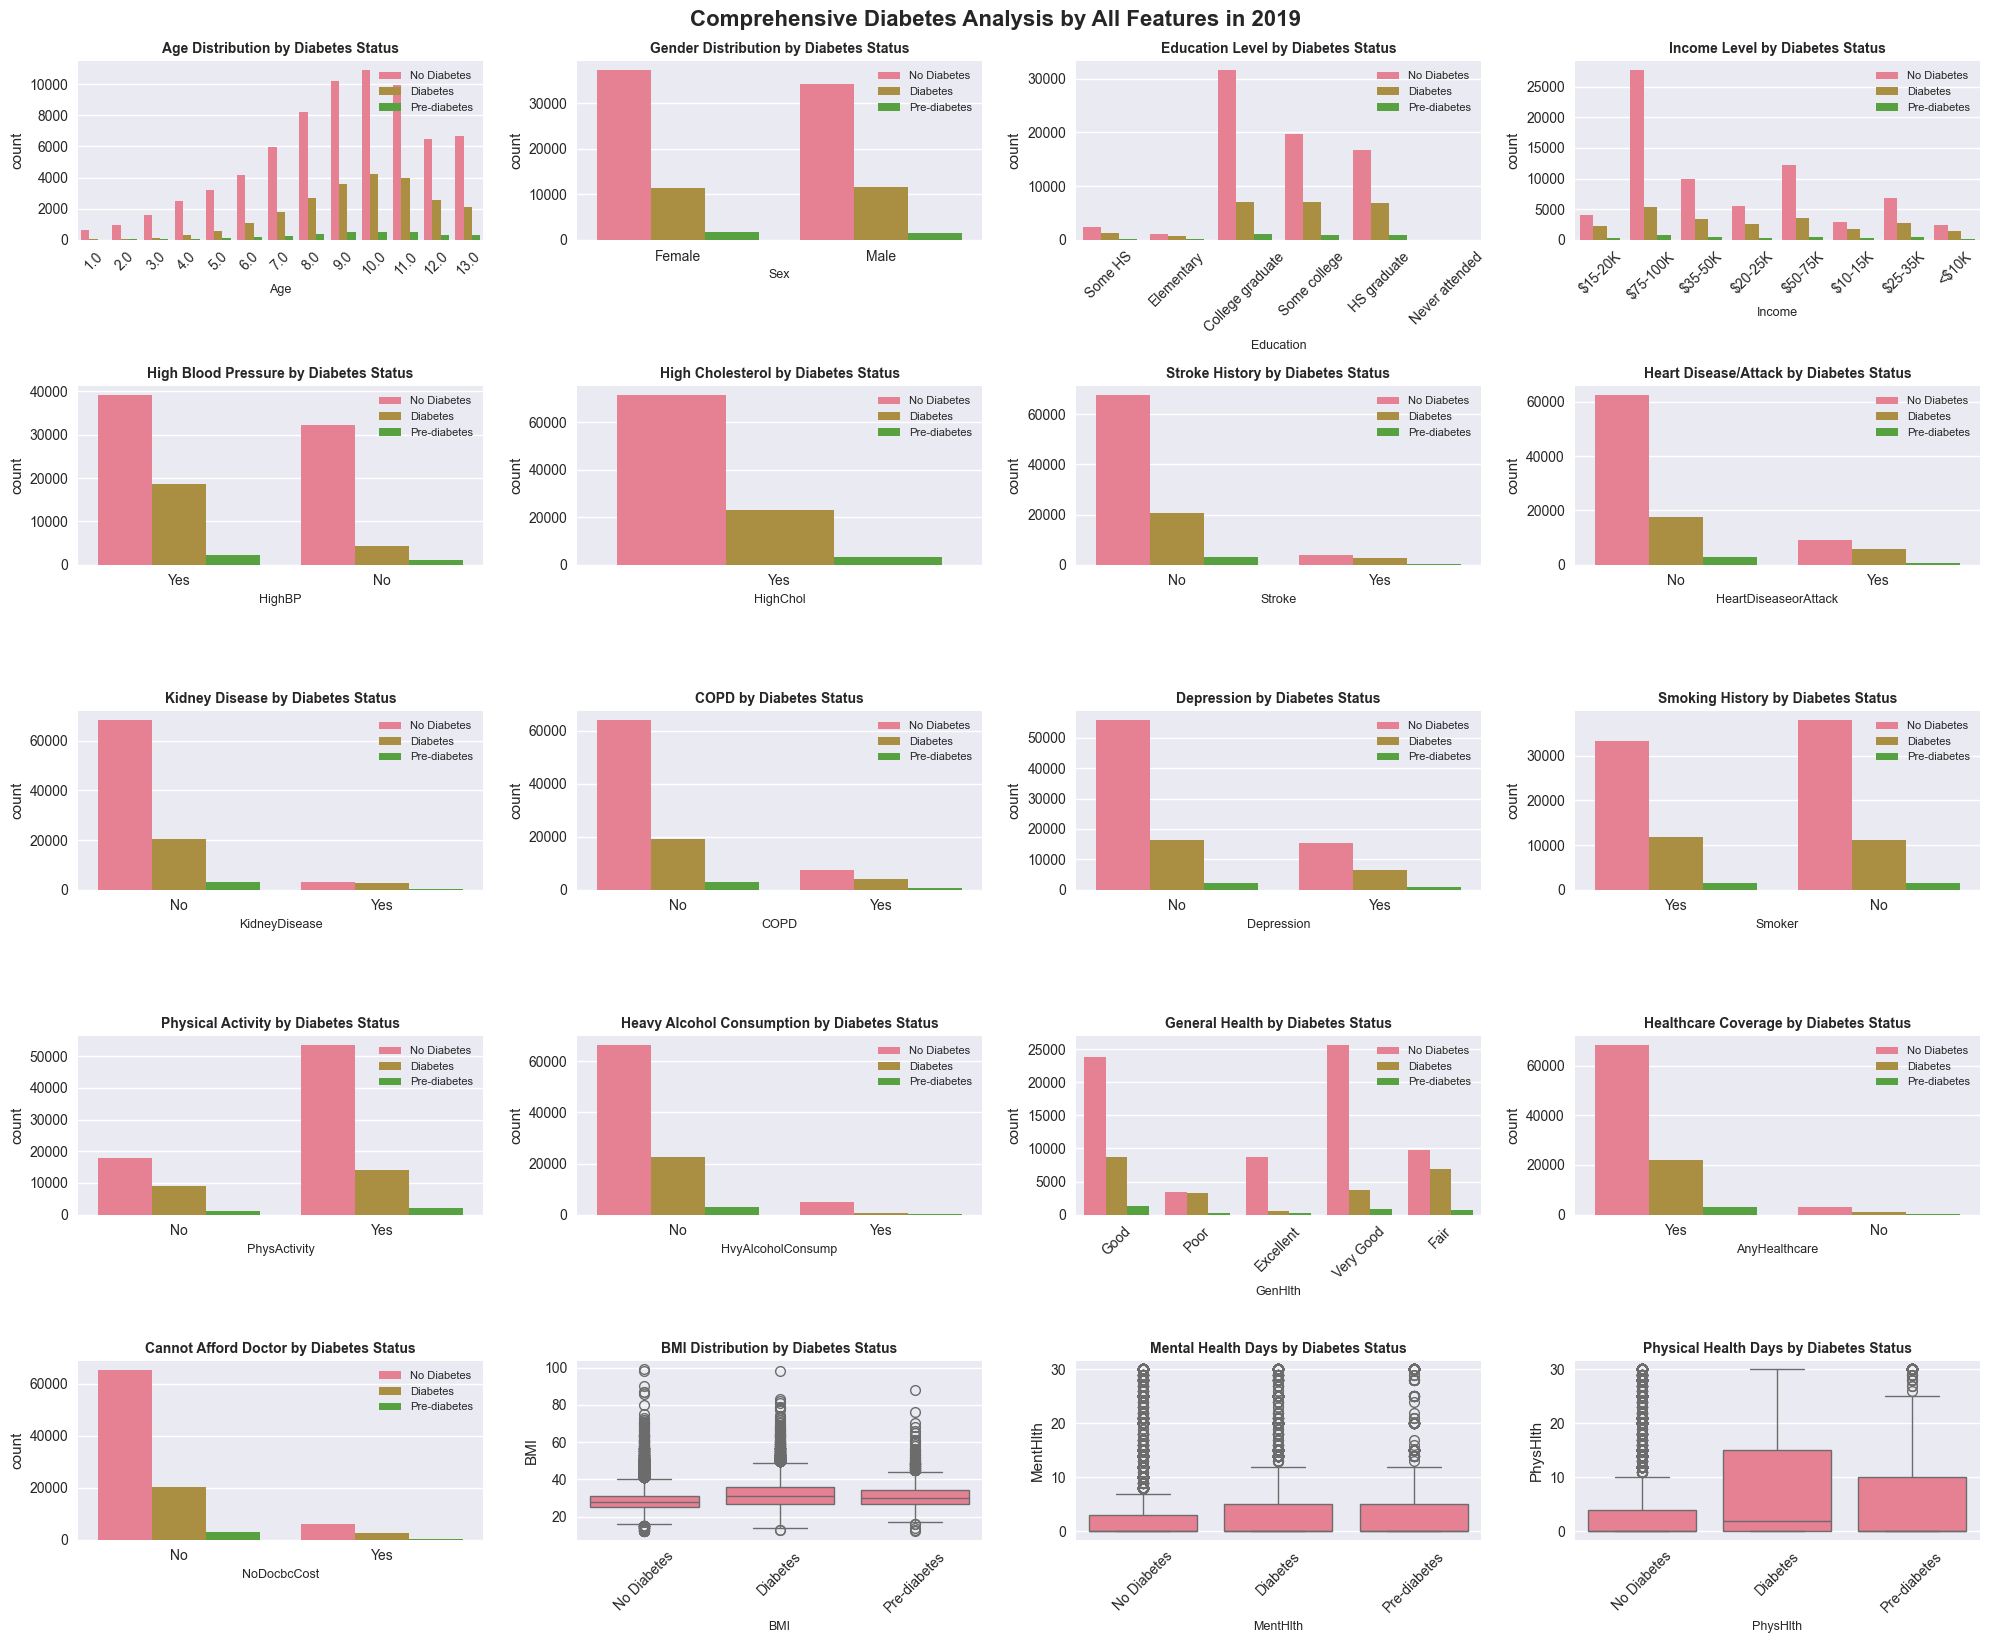

In [30]:
# Comprehensive feature and diabetes analysis in 2019
plot_comprehensive_diabetes_analysis(df=df_2019, year=2019)

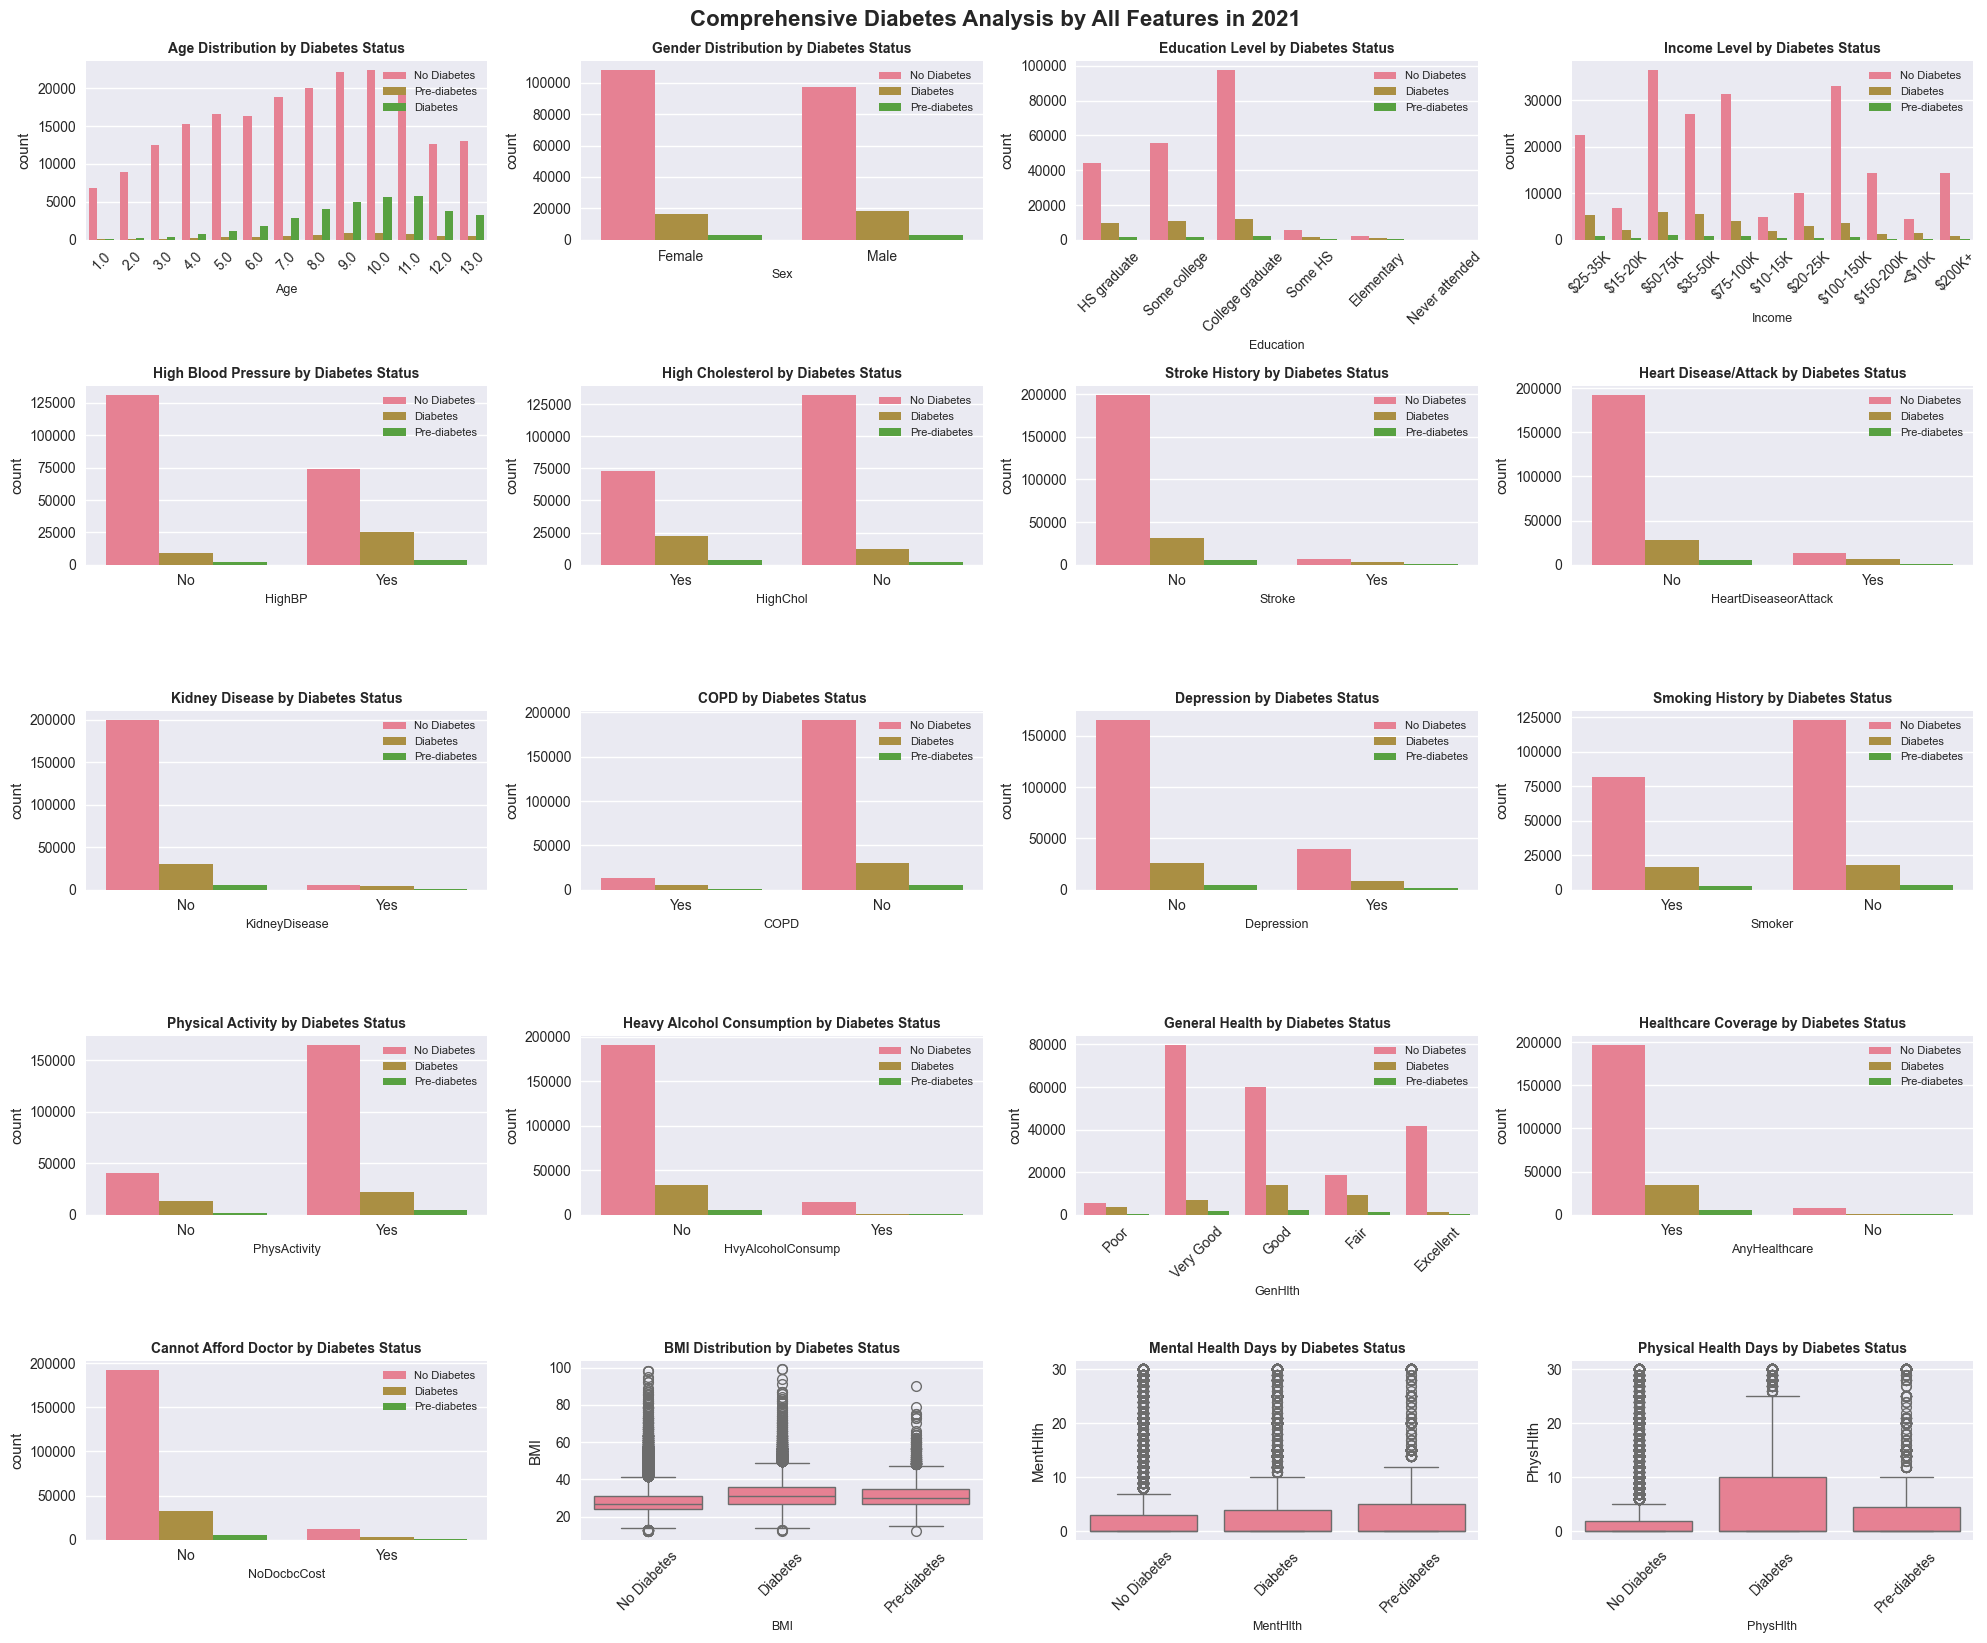

In [31]:
# Comprehensive feature and diabetes analysis in 2021
plot_comprehensive_diabetes_analysis(df=df_2021, year=2021)

### **2.9 Additional health conditions & factors analysis**

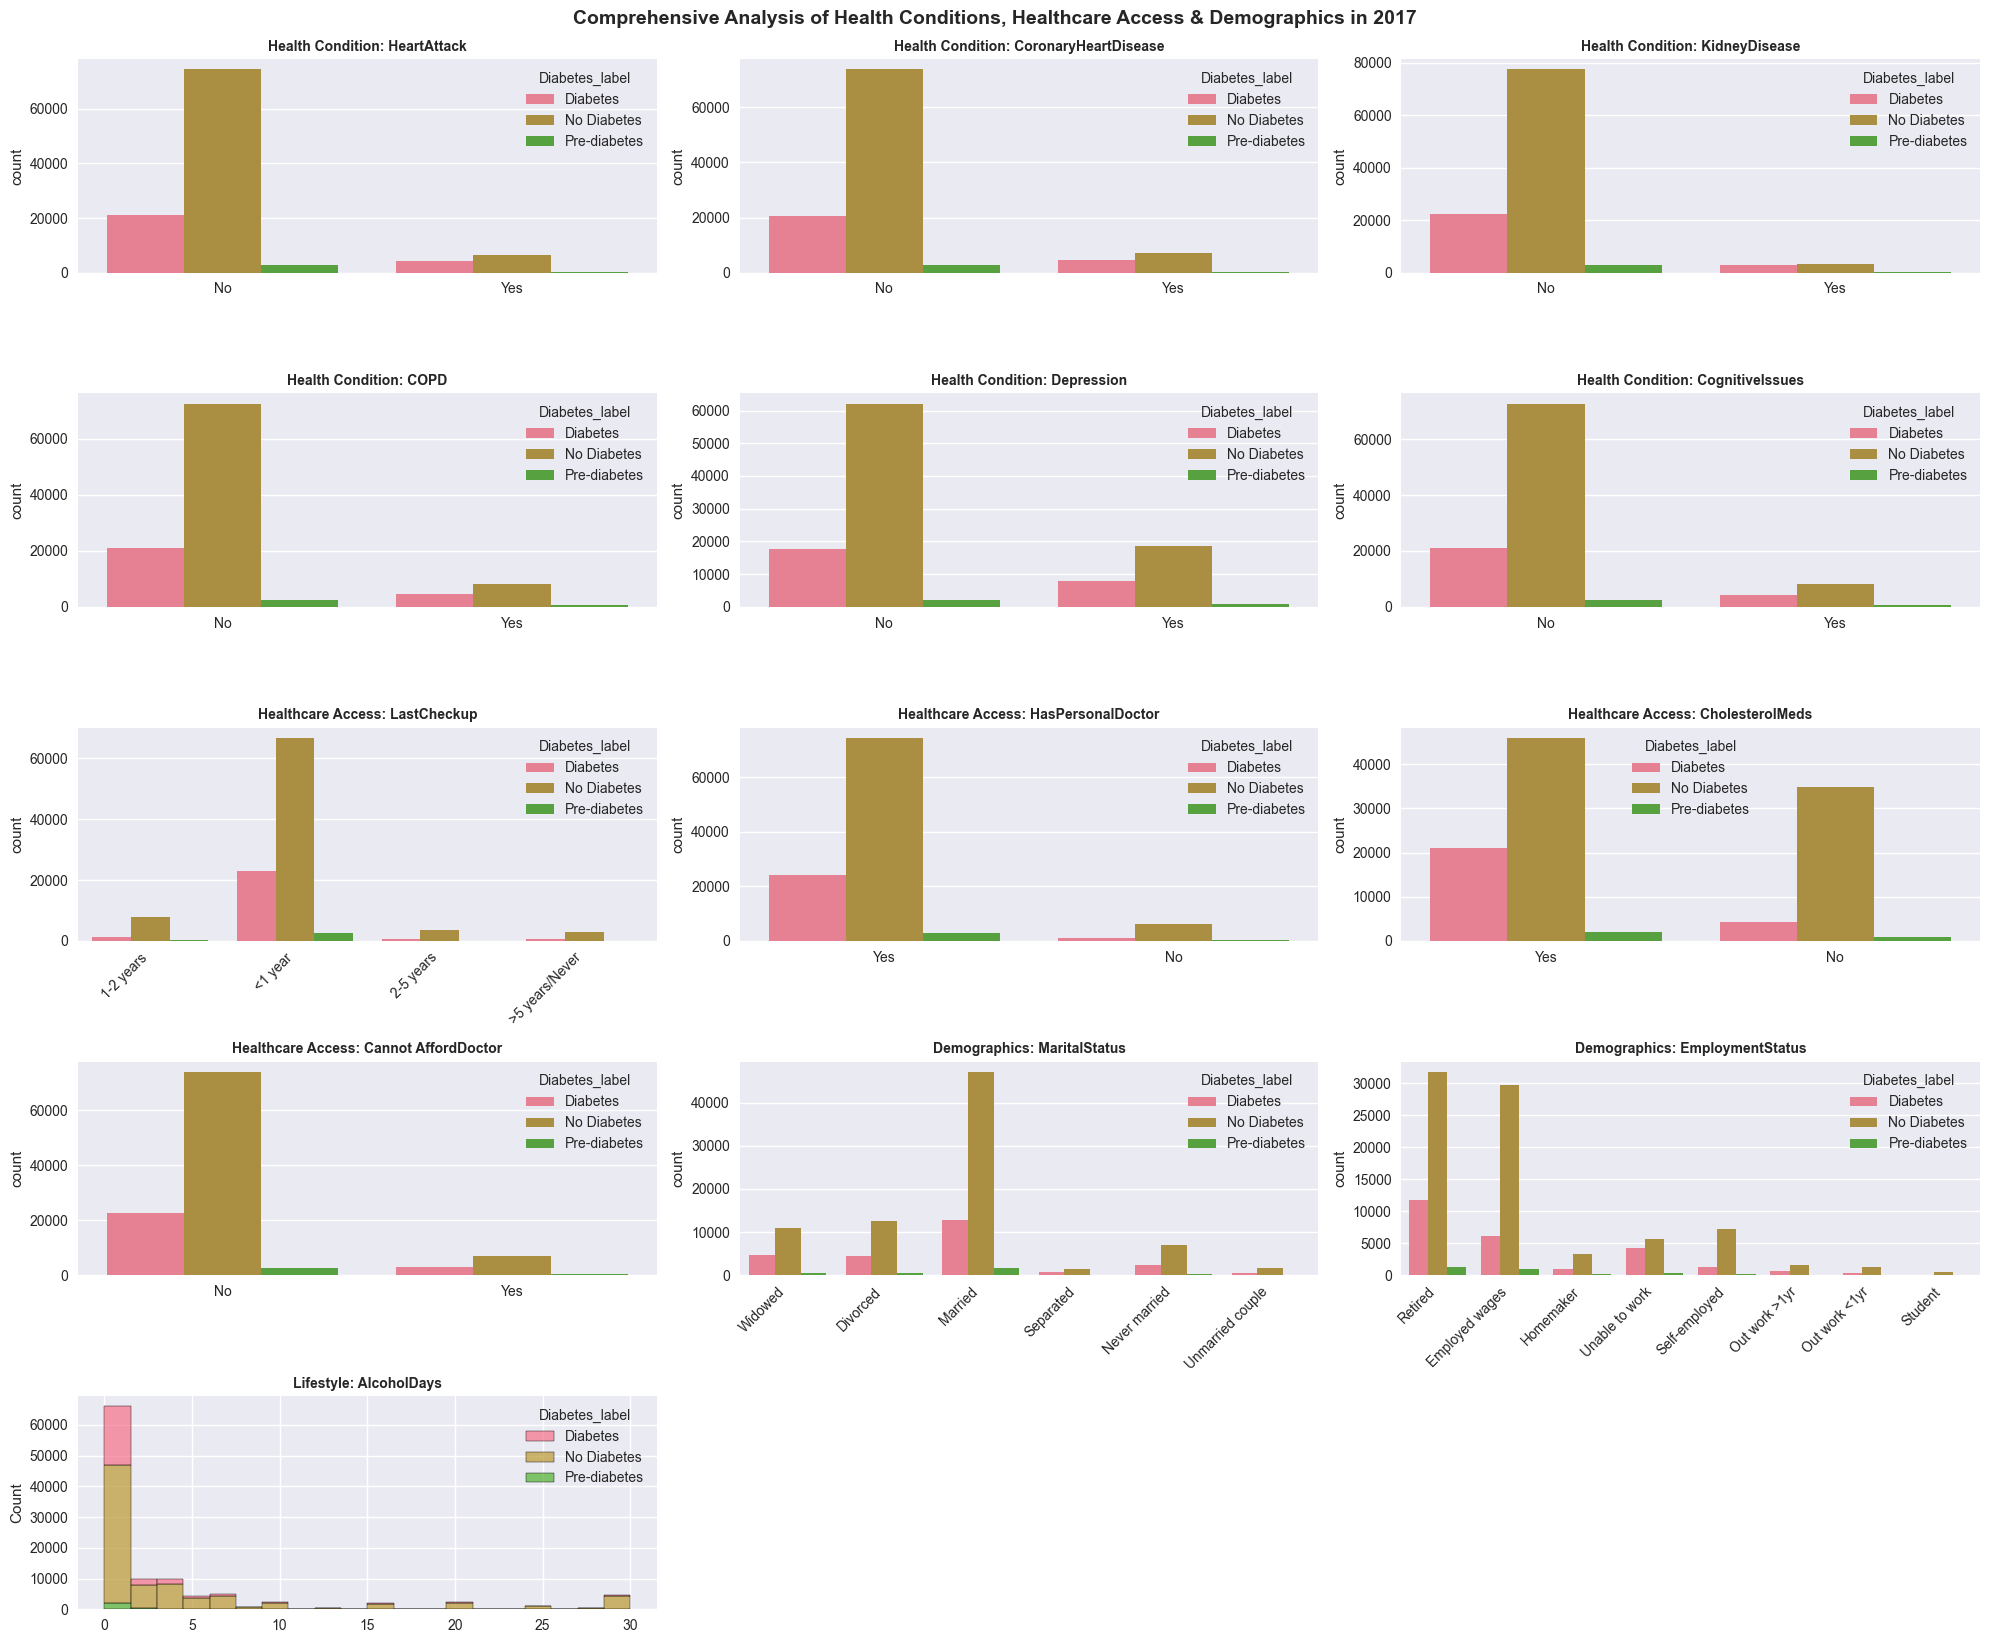

In [32]:
# Additional health conditions & factors analysis in 2017
plot_additional_features_analysis(df=df_2017, year=2017)

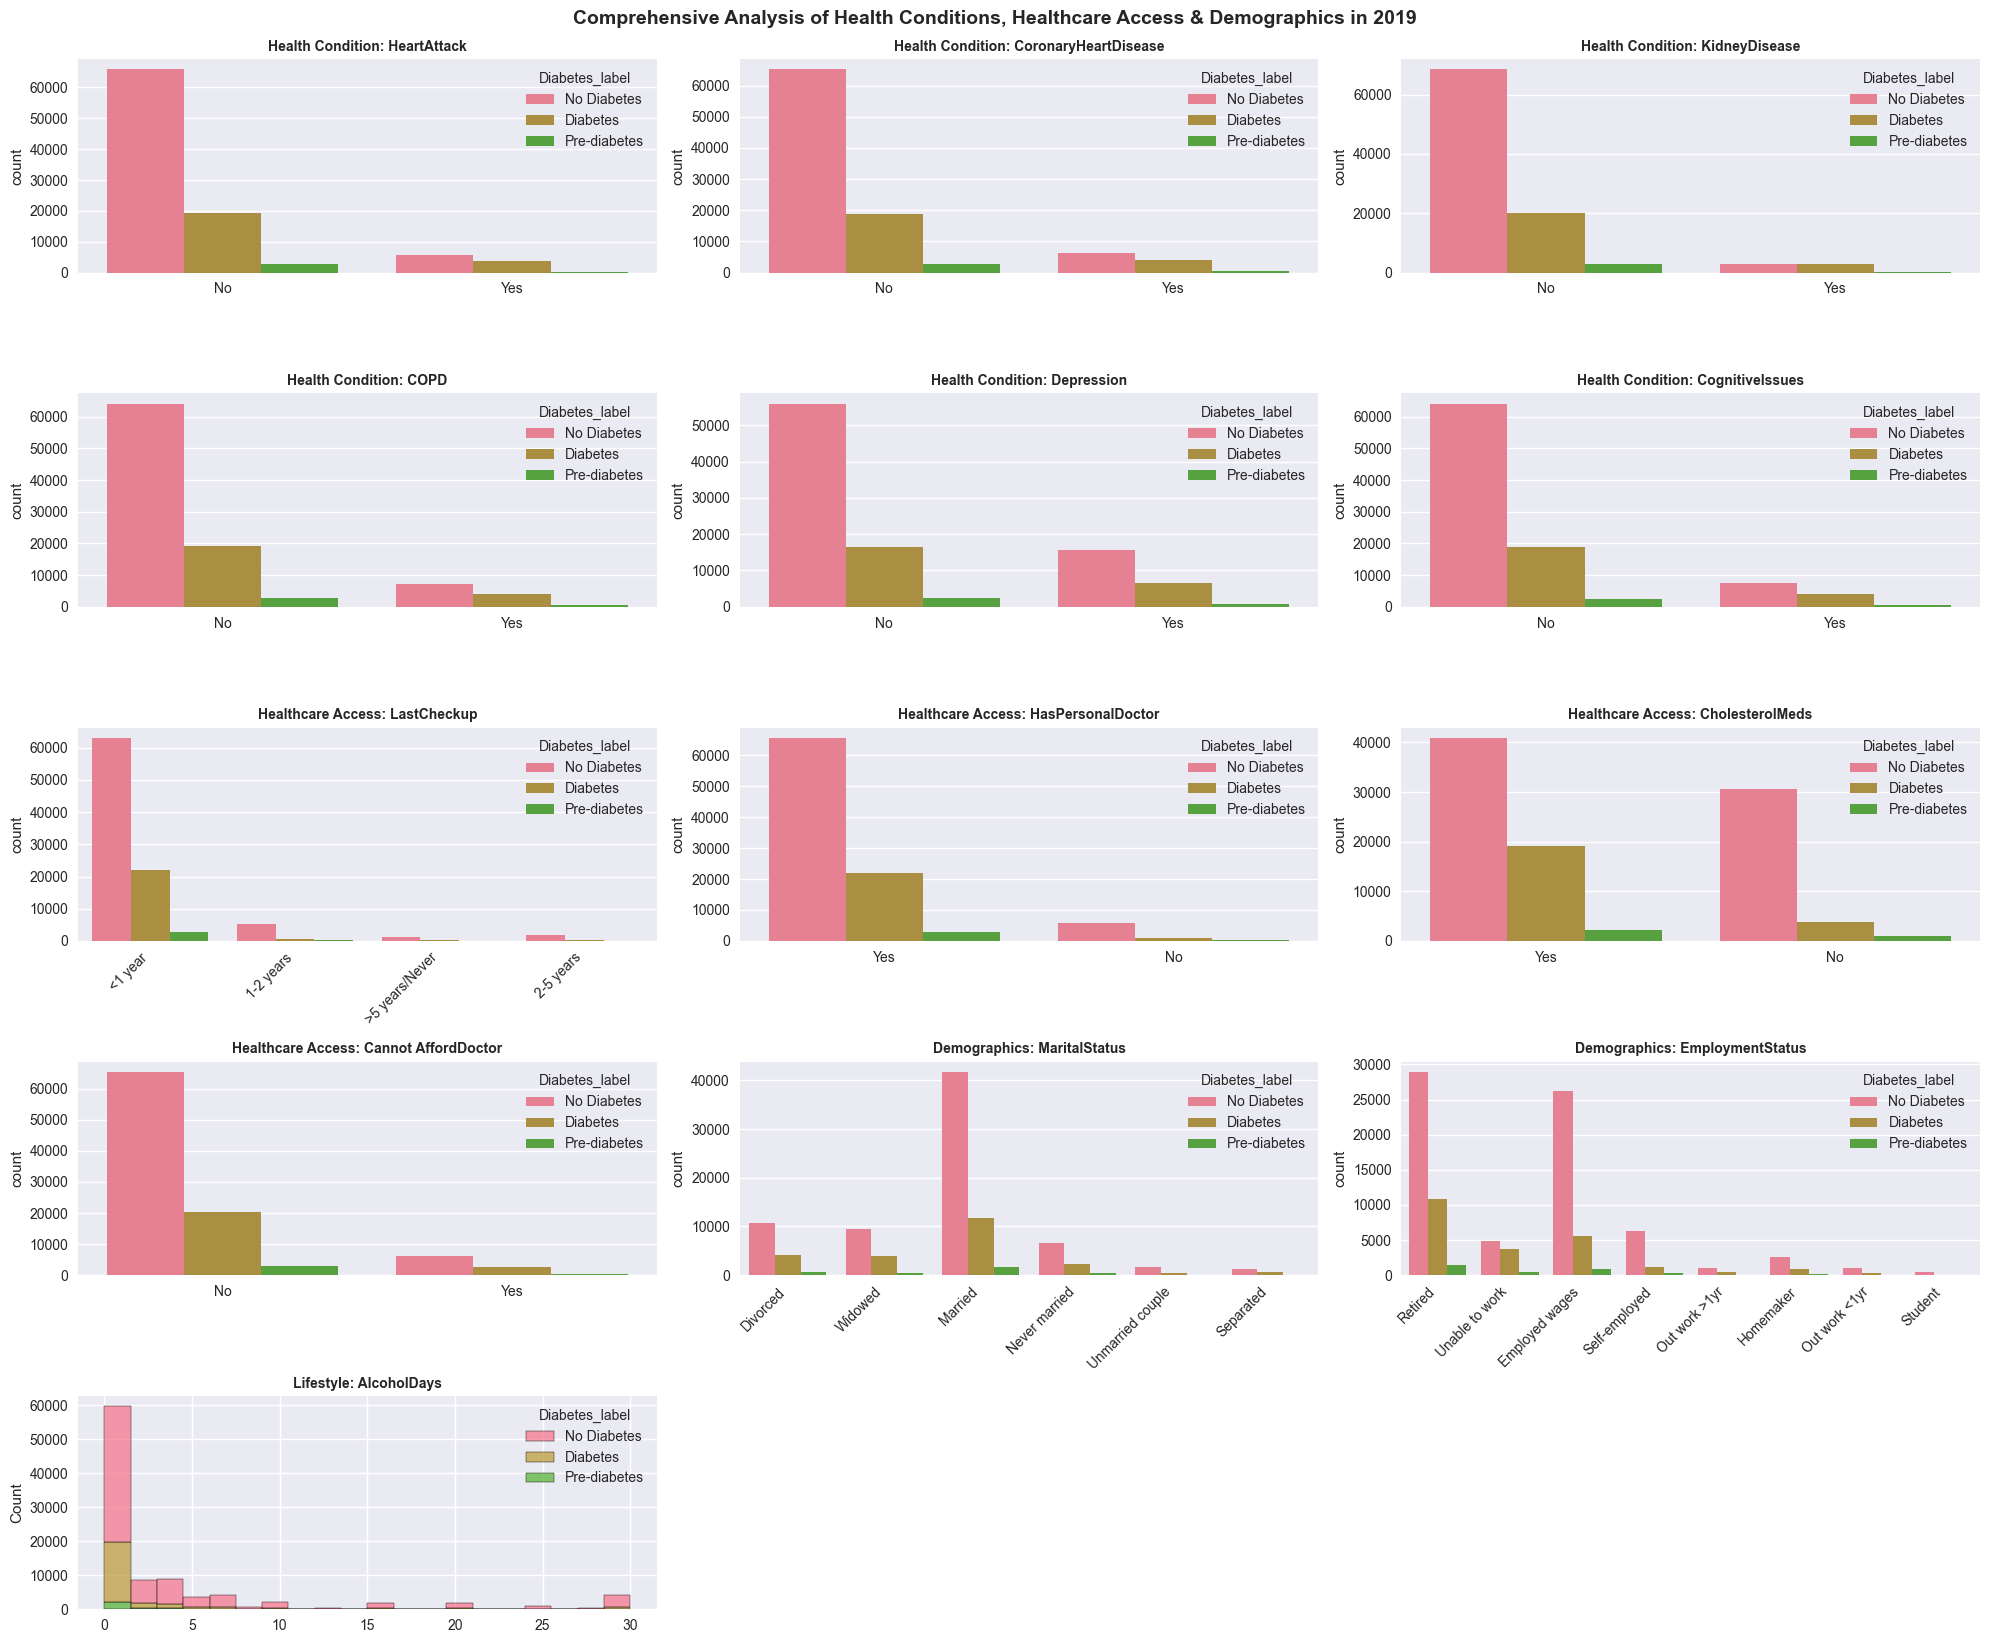

In [33]:
# Additional health conditions & factors analysis in 2019
plot_additional_features_analysis(df=df_2019, year=2019)

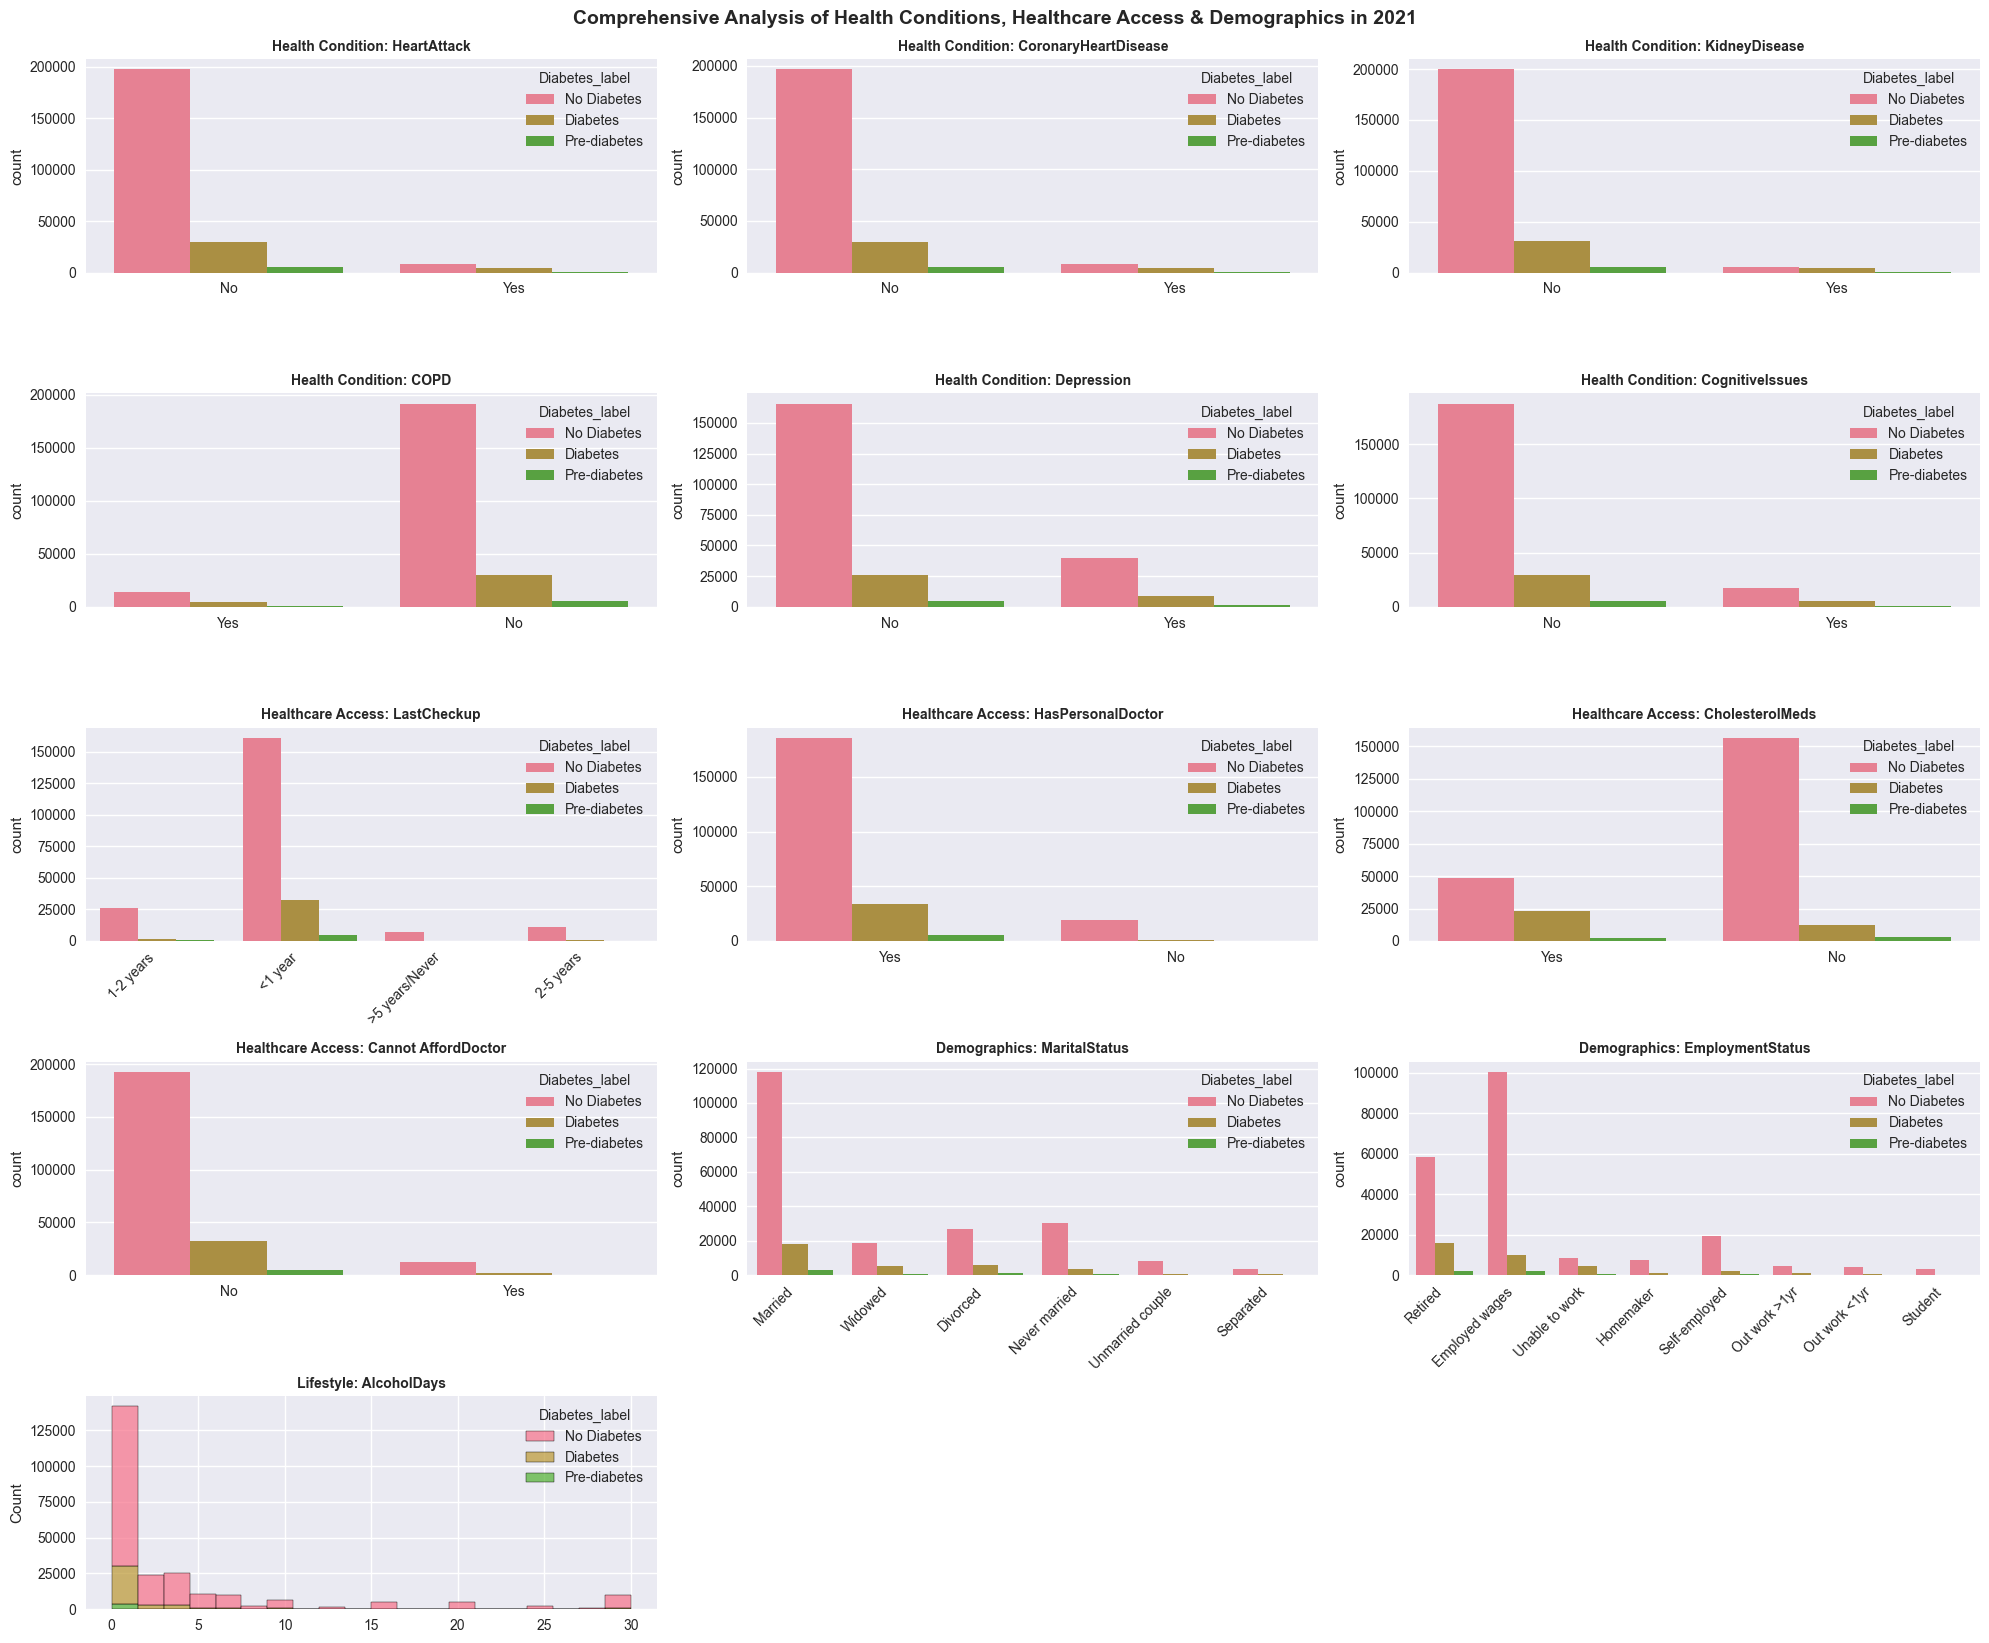

In [34]:
# Additional health conditions & factors analysis in 2021
plot_additional_features_analysis(df=df_2021, year=2021)

### **2.10 Diabetes prevalence heatmap**

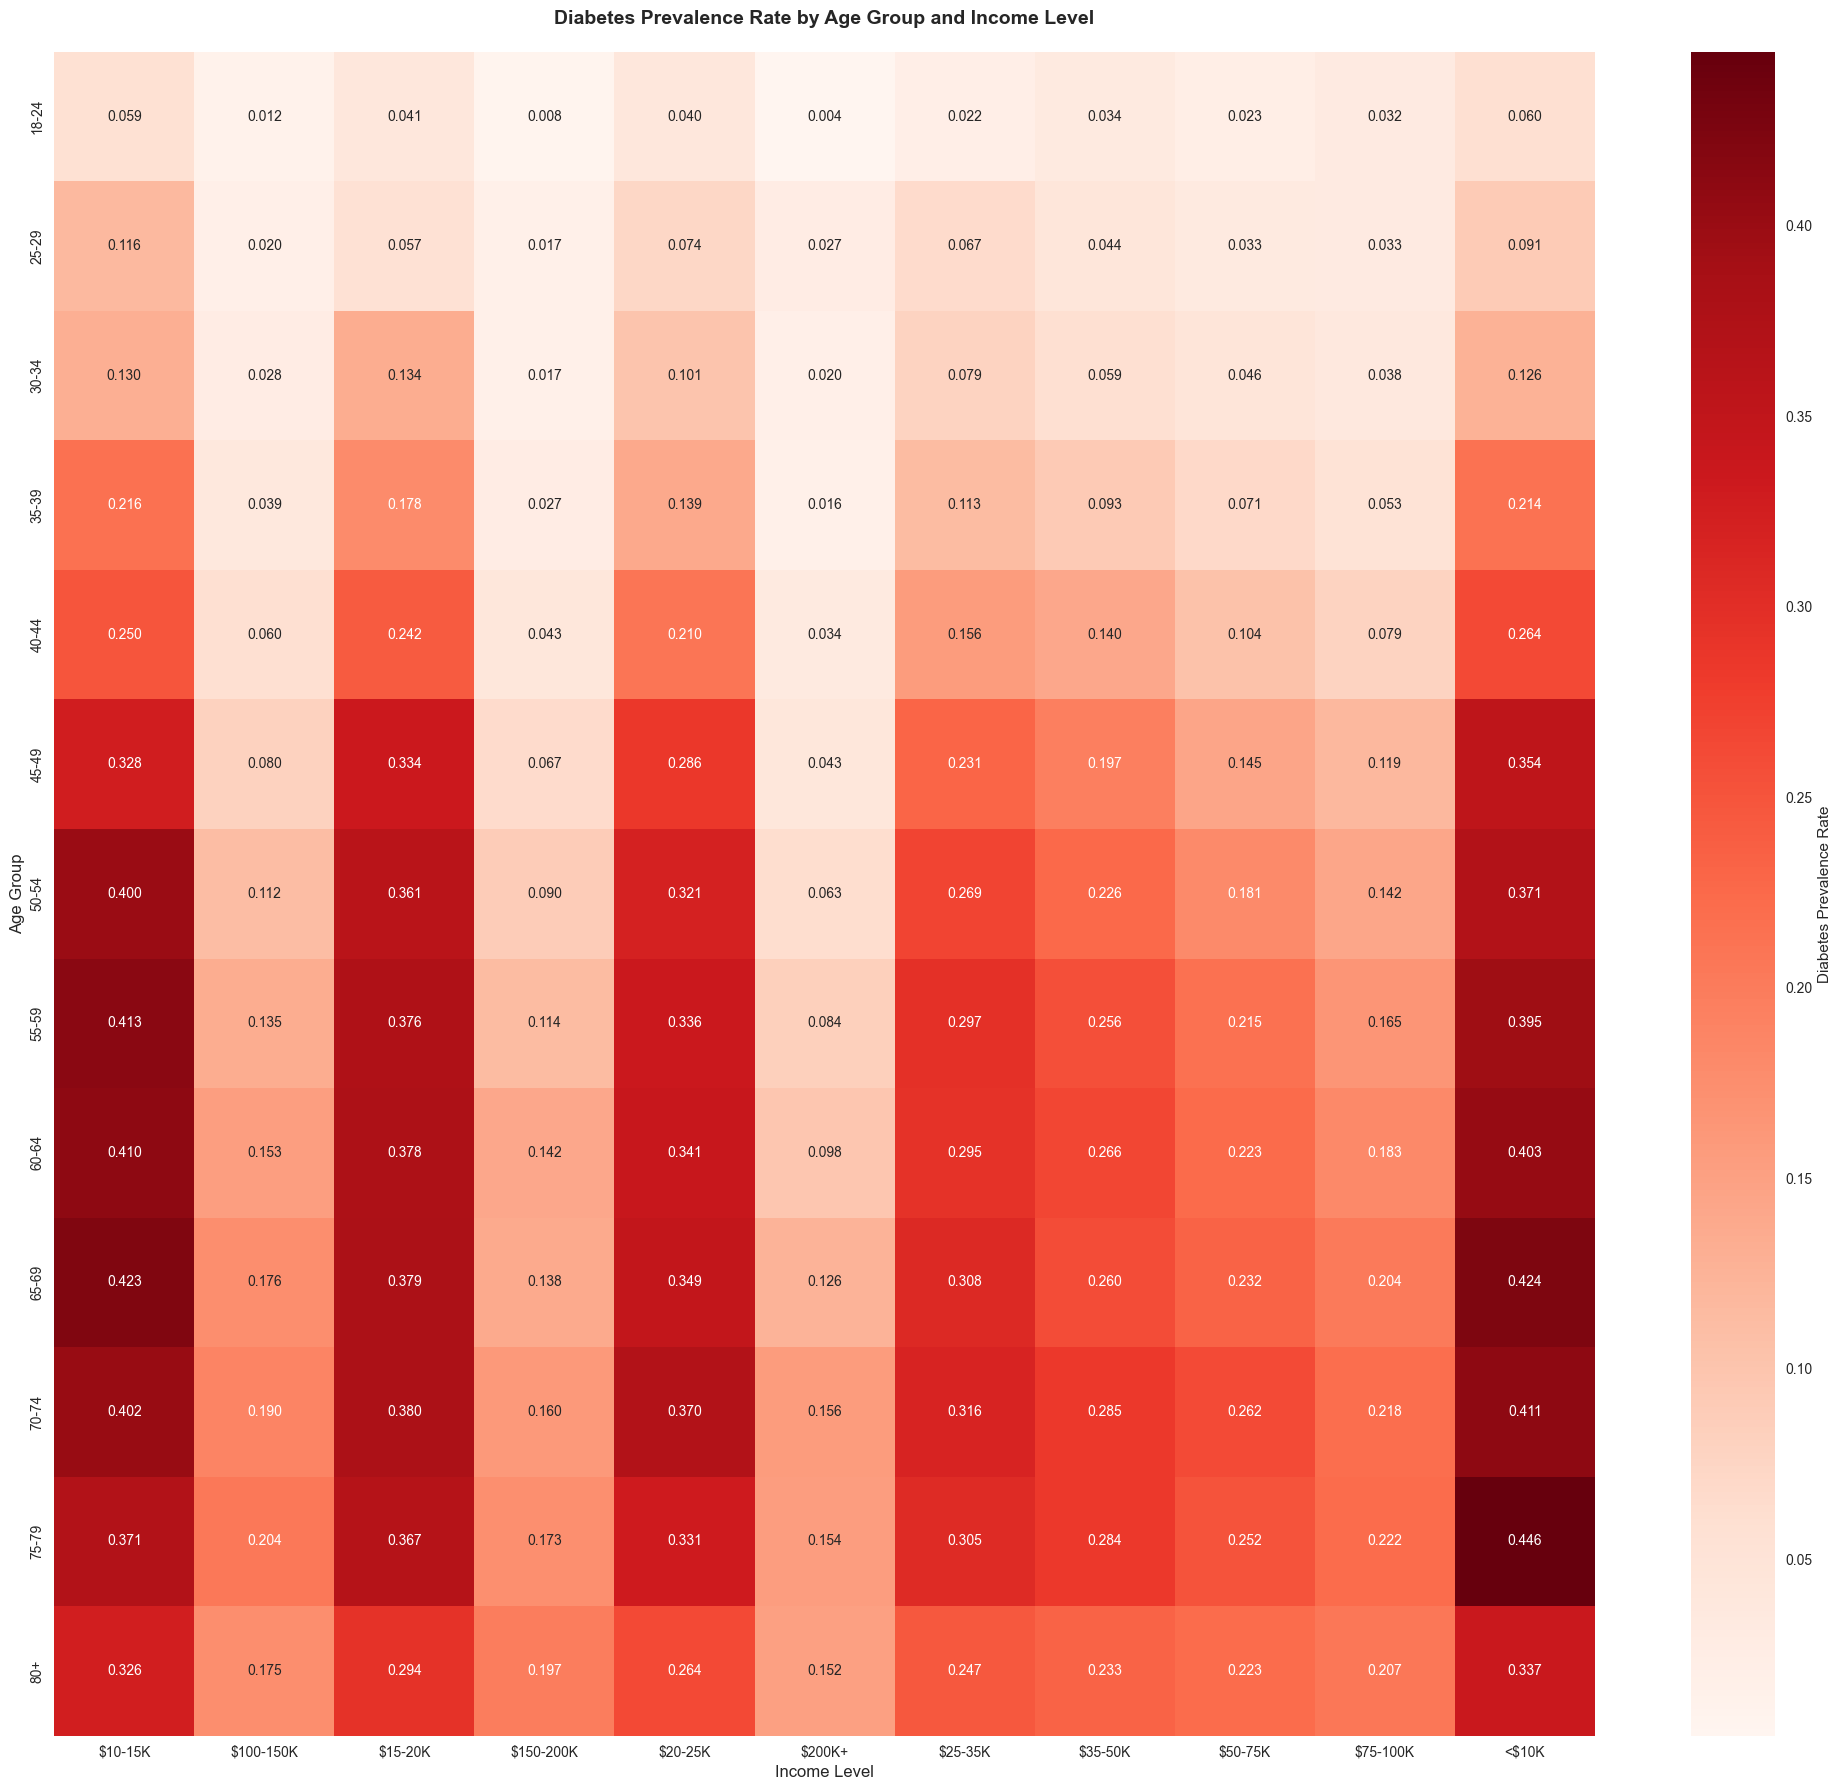

In [35]:
plot_diabetes_prevalence_heatmap(df=df)

### **2.11 Risk factor analysis**

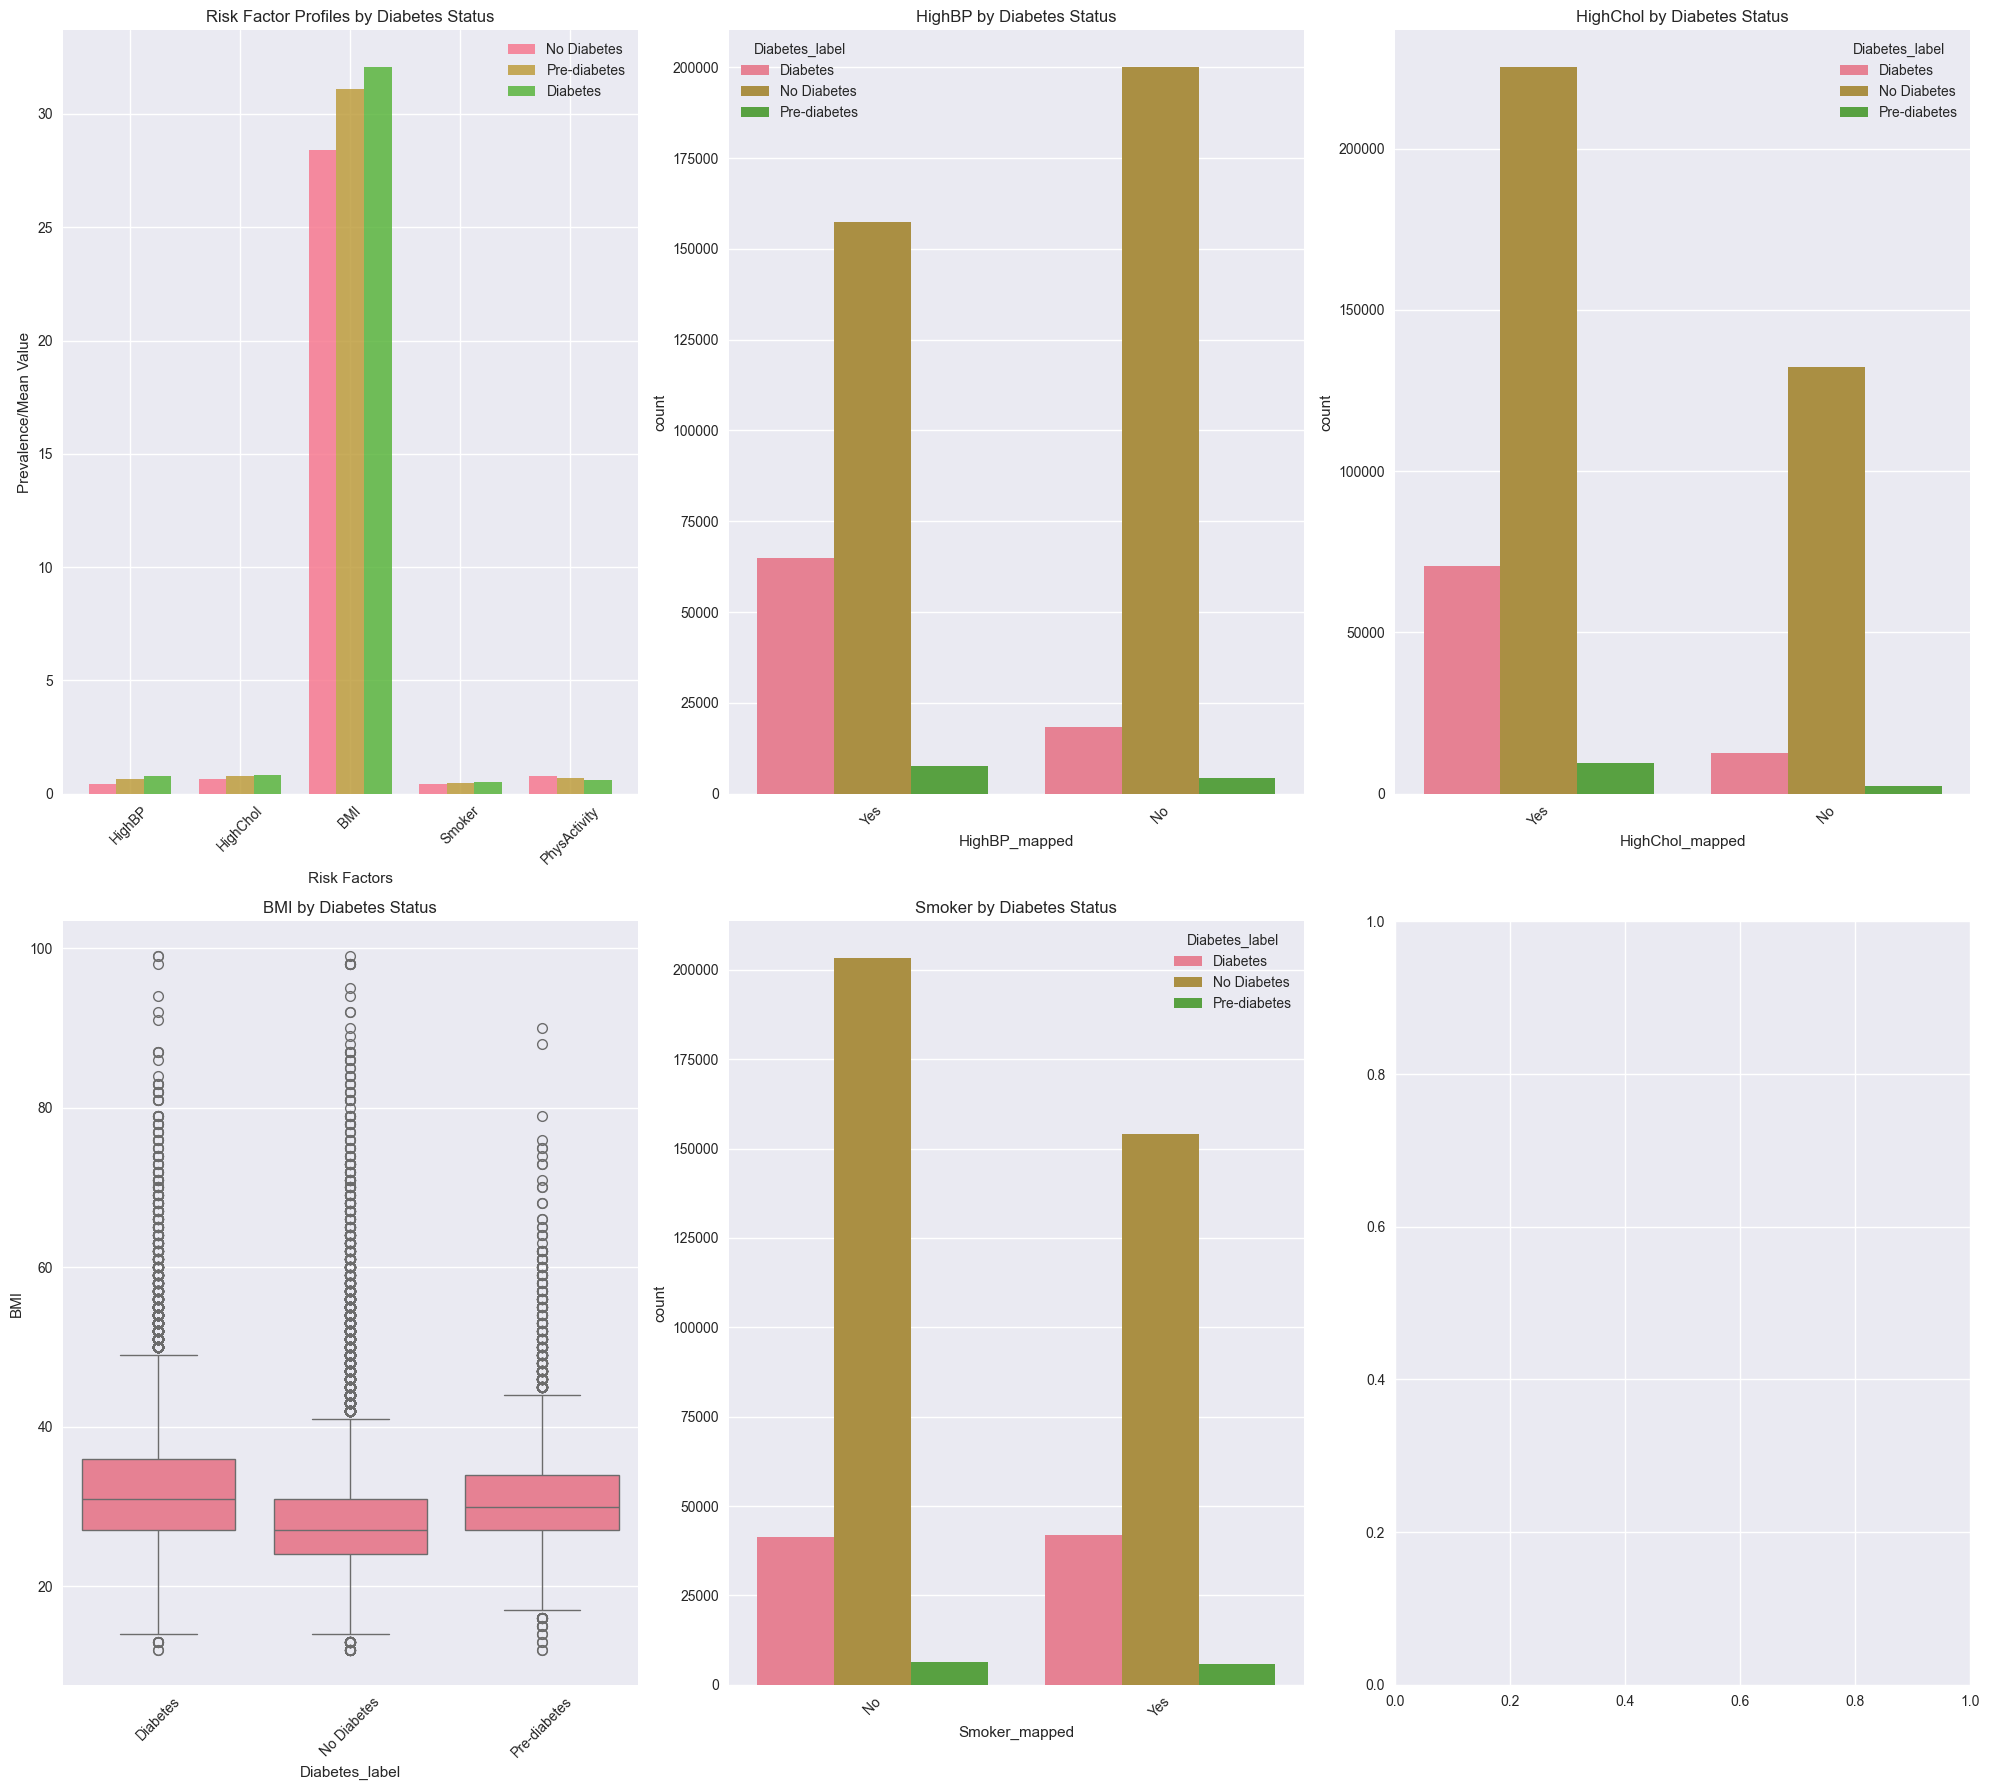

In [36]:
plot_risk_factor_analysis(df=df)

### **2.12 The correlation score between features**

In [37]:
# Calculate correlation matrix between all features
df.corr()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,...,CoronaryHeartDisease,COPD,AlcoholDays,LastCheckup,HasPersonalDoctor,CholesterolMeds,MaritalStatus,EmploymentStatus,CannotAffordDoctor,Year
Diabetes,1.000000,0.264768,0.184315,0.067588,0.226471,0.057189,0.102406,0.167511,-0.144768,-0.066423,...,0.146072,0.104510,-0.119312,-0.083579,0.074540,0.294589,0.009914,0.179885,0.037455,-0.109800
HighBP,0.264768,1.000000,0.281811,0.092629,0.197398,0.098681,0.128449,0.203320,-0.132049,-0.003153,...,0.178102,0.118563,-0.025459,-0.113381,0.108759,0.357185,-0.014420,0.256775,0.013975,-0.176515
HighChol,0.184315,0.281811,1.000000,0.104090,0.072144,0.093808,0.082336,0.152794,-0.091072,-0.014453,...,0.137438,0.098999,-0.007276,-0.093263,0.087019,0.523480,-0.075258,0.205117,0.029835,-0.582057
CholCheck,0.067588,0.092629,0.104090,1.000000,0.029472,-0.007895,0.023981,0.041619,-0.005881,-0.025080,...,0.037928,0.024752,-0.018095,0.079817,0.244699,0.140415,-0.052172,0.072044,-0.068208,-0.055863
BMI,0.226471,0.197398,0.072144,0.029472,1.000000,0.007995,0.011588,0.036250,-0.158278,-0.038145,...,0.033515,0.054982,-0.099300,-0.028859,0.027459,0.095117,0.026741,-0.016979,0.056250,-0.029243
Smoker,0.057189,0.098681,0.093808,-0.007895,0.007995,1.000000,0.062629,0.121516,-0.089839,0.094141,...,0.099840,0.217591,0.079056,-0.026978,-0.000540,0.101263,0.017677,0.126729,0.051773,-0.070265
Stroke,0.102406,0.128449,0.082336,0.023981,0.011588,0.062629,1.000000,0.187995,-0.078948,-0.018034,...,0.149582,0.110455,-0.039187,-0.034860,0.026996,0.126930,0.013680,0.152961,0.036978,-0.053859
HeartDiseaseorAttack,0.167511,0.203320,0.152794,0.041619,0.036250,0.121516,0.187995,1.000000,-0.094393,-0.031701,...,0.821965,0.185311,-0.036973,-0.052052,0.046644,0.248703,-0.013402,0.203605,0.032833,-0.100322
PhysActivity,-0.144768,-0.132049,-0.091072,-0.005881,-0.158278,-0.089839,-0.078948,-0.094393,1.000000,0.018445,...,-0.077290,-0.145429,0.089363,0.031223,0.005508,-0.108214,-0.044301,-0.125567,-0.066290,0.074175
HvyAlcoholConsump,-0.066423,-0.003153,-0.014453,-0.025080,-0.038145,0.094141,-0.018034,-0.031701,0.018445,1.000000,...,-0.028073,-0.009203,0.452761,0.016115,-0.030426,-0.036162,0.013019,-0.047795,0.005975,0.010151


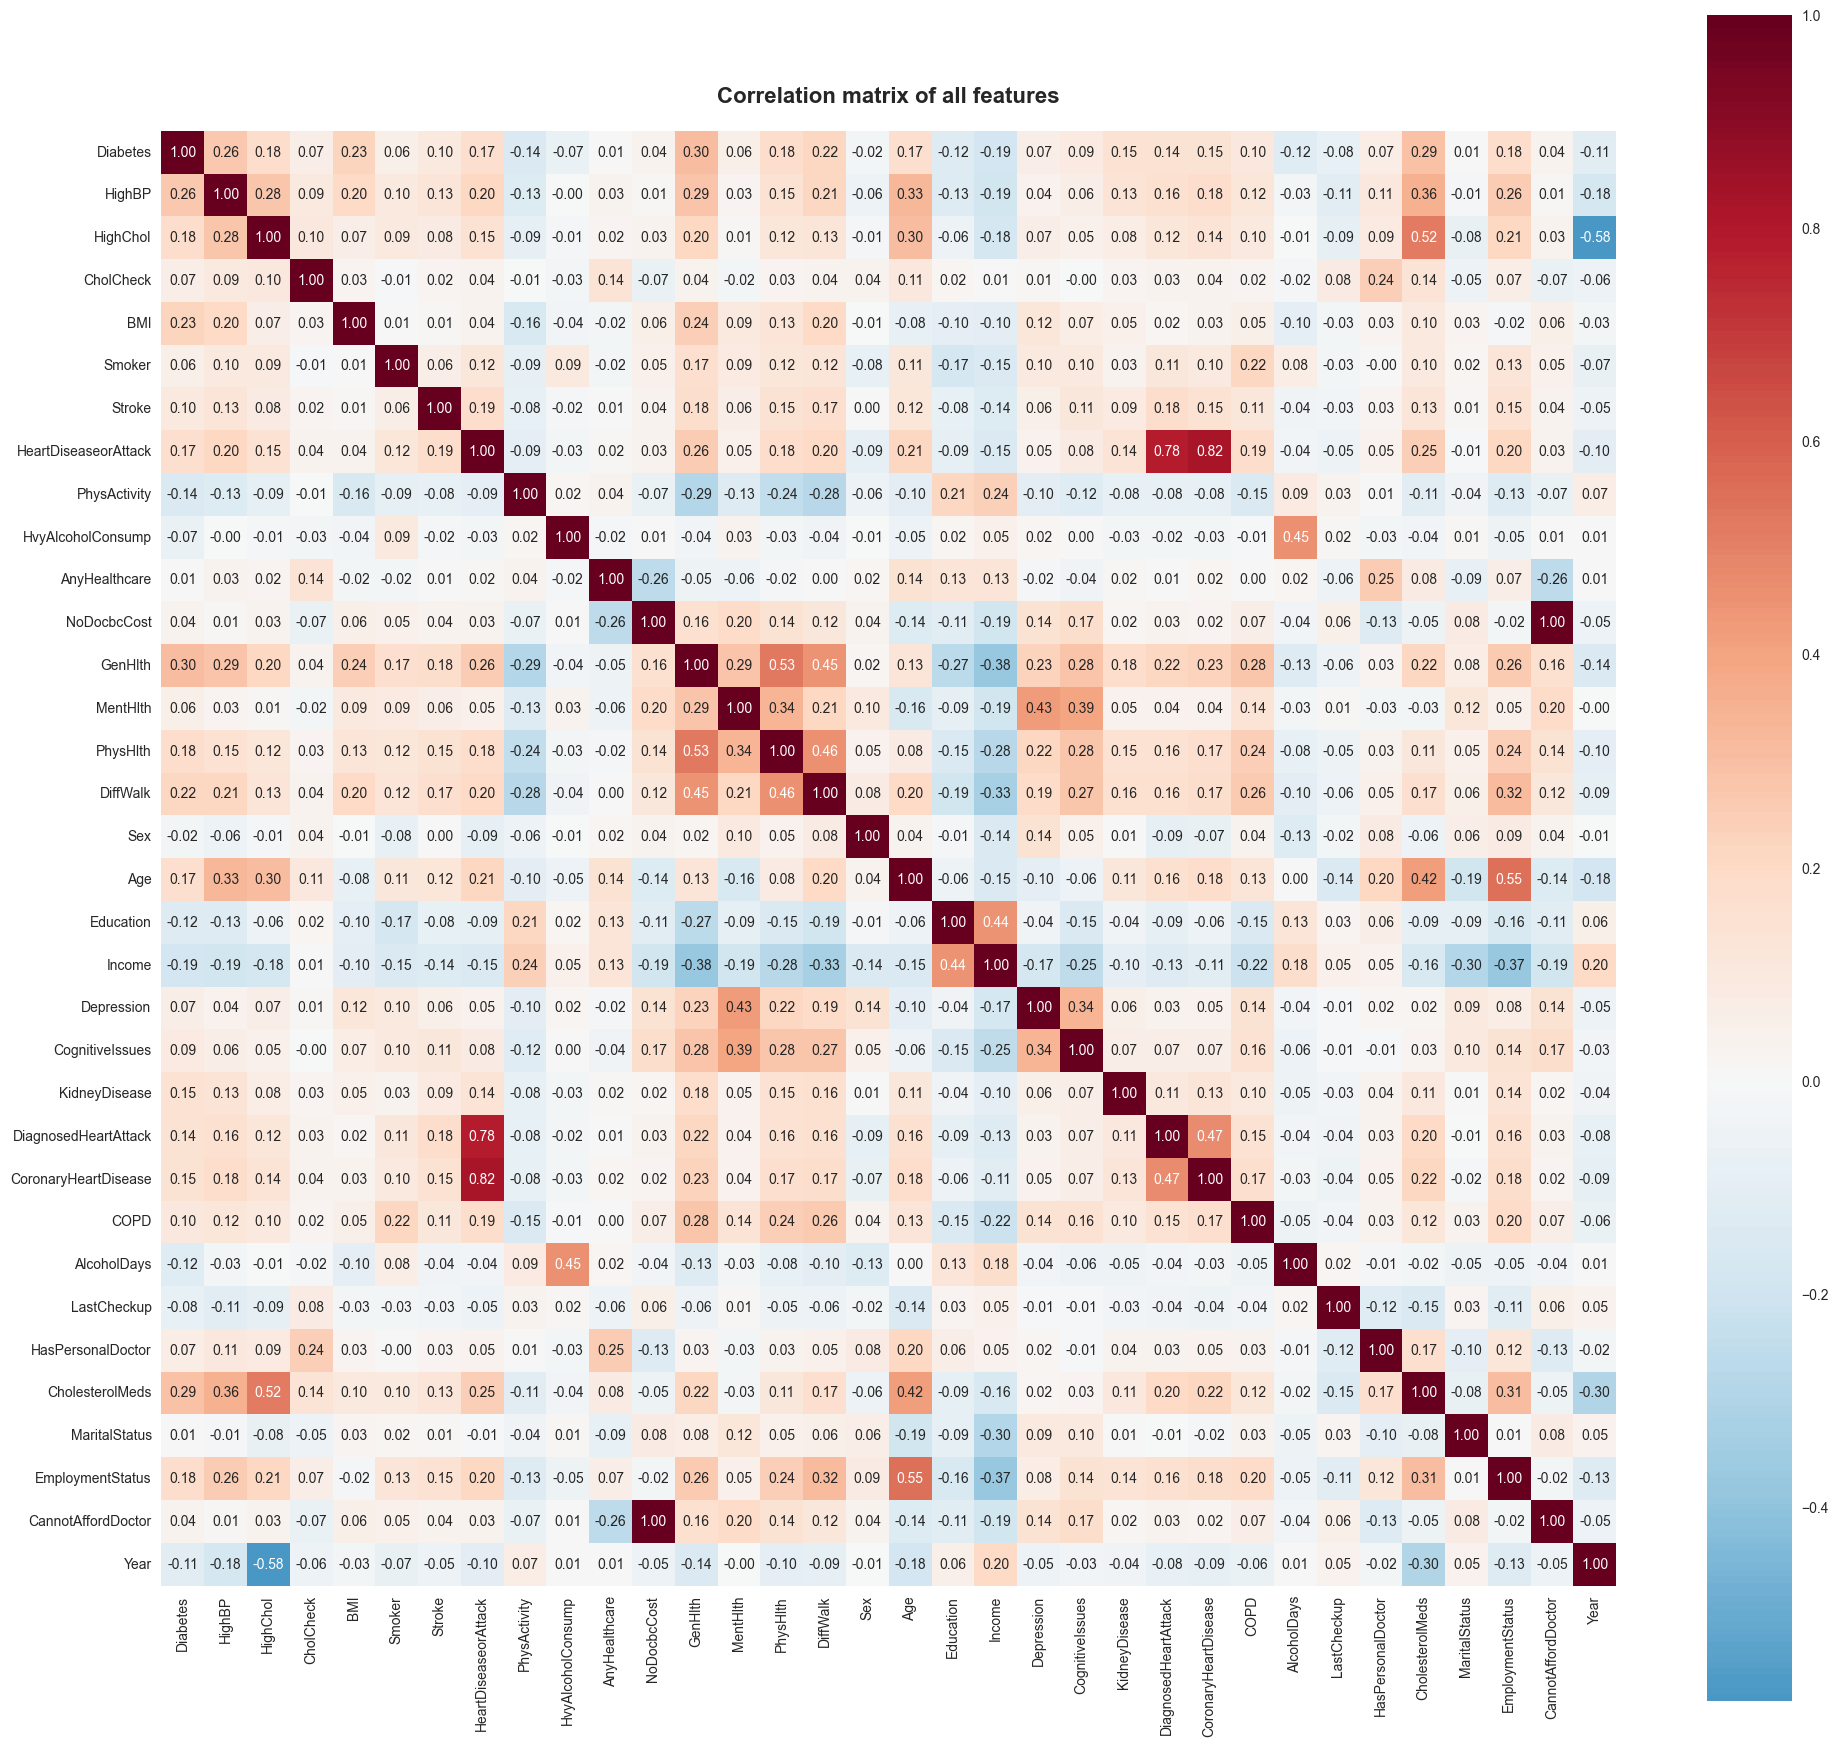

In [38]:
# Display correlation heatmap
plot_correlation_matrix(
    df=df,
    title="Correlation matrix of all features"
)

### **2.13 Class distribution**

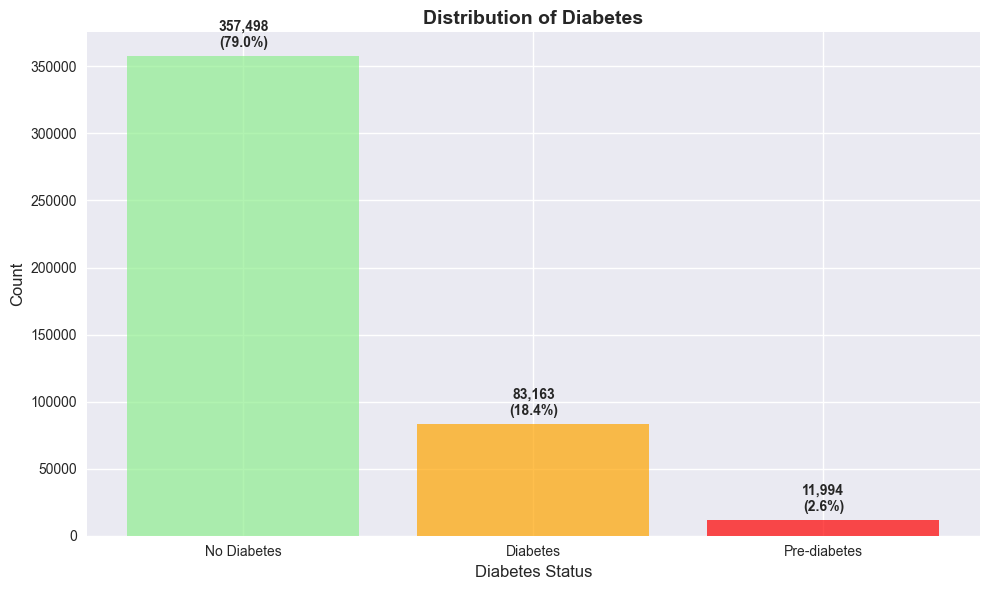

In [39]:
# Plot distribution of classes in the dataset
plot_class_distribution(
    y=df["Diabetes"],
    title="Distribution of Diabetes"
)

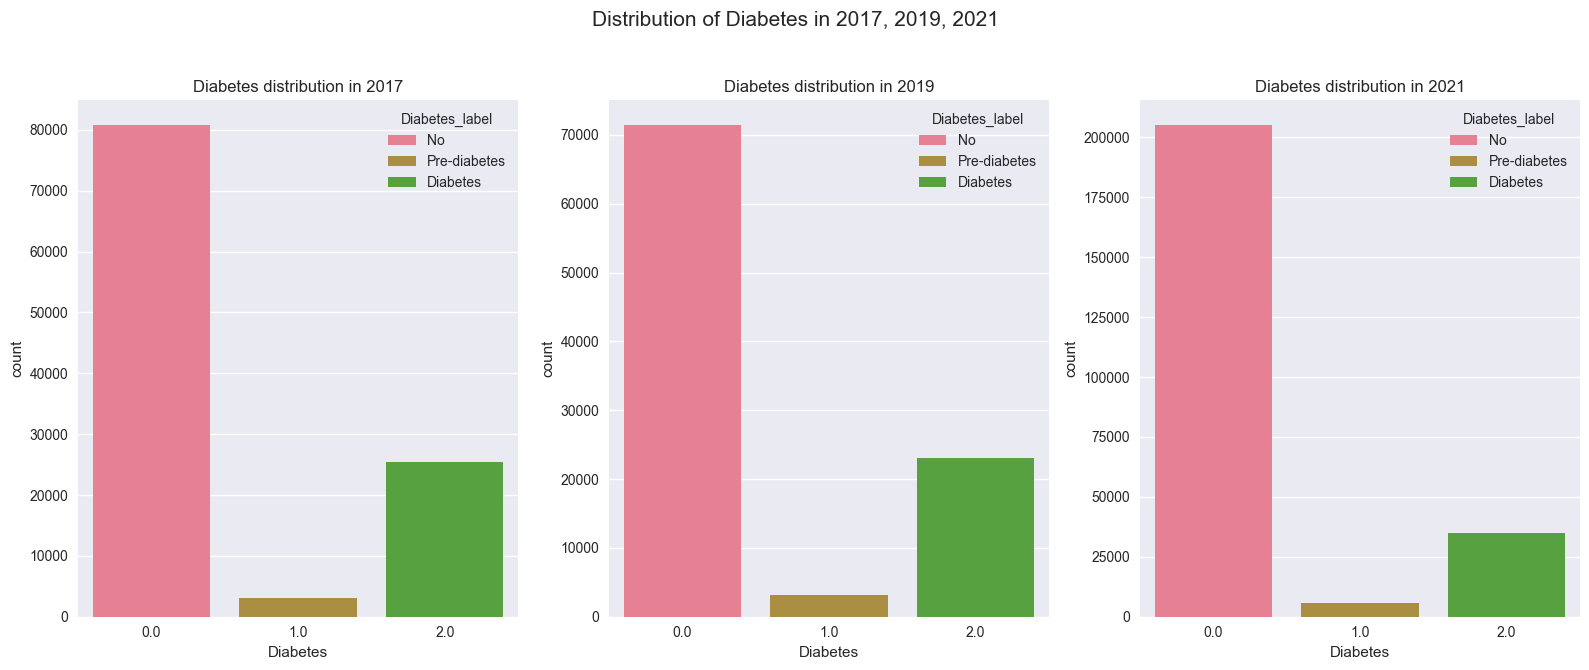

In [40]:
diabetes_mapping = {
    0: "No",
    1: "Pre-diabetes",
    2: "Diabetes"
}
df_2017['Diabetes_label'] = df_2017['Diabetes'].map(diabetes_mapping)
df_2019['Diabetes_label'] = df_2019['Diabetes'].map(diabetes_mapping)
df_2021['Diabetes_label'] = df_2021['Diabetes'].map(diabetes_mapping)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 7))

# General Health distribution
sns.countplot(data=df_2017, x="Diabetes", hue="Diabetes_label", ax=ax[0])
ax[0].set_title('Diabetes distribution in 2017')
ax[0].set_xlabel('Diabetes')

sns.countplot(data=df_2019, x="Diabetes", hue="Diabetes_label", ax=ax[1])
ax[1].set_title('Diabetes distribution in 2019')
ax[1].set_xlabel('Diabetes')

sns.countplot(data=df_2021, x="Diabetes", hue="Diabetes_label", ax=ax[2])
ax[2].set_title('Diabetes distribution in 2021')
ax[2].set_xlabel('Diabetes')

plt.tight_layout()
fig.suptitle("Distribution of Diabetes in 2017, 2019, 2021", fontsize=15)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()